<a href="https://colab.research.google.com/github/JMK9904/ba_framing_yt-kommentare/blob/main/BA_final_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip uninstall gensim -y
#!pip install gensim==4.3.3
!pip install bertopic sentence-transformers umap-learn hdbscan gensim nltk dask[complete] HanTa scikit-optimize
!pip install octis==1.14.0 --no-deps


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.2/14.2 MB 133.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.0/131.0 kB 13.8 MB/s eta 0:00:00


In [ ]:
!pip uninstall torchao


Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/torchao-0.10.0.dist-info/*
    /usr/local/lib/python3.12/dist-packages/torchao/*
Proceed (Y/n)? y
  Successfully uninstalled torchao-0.10.0


In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
#import optuna
import numpy as np
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer
import umap
import hdbscan
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from pathlib import Path
import pandas as pd
import numpy as np
import re
from HanTa.HanoverTagger import HanoverTagger as ht
import dask.dataframe as dd
from octis.optimization.optimizer import Optimizer
from skopt.space.space import Real

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filtered_data = dd.read_parquet("/content/drive/MyDrive/Bachelor Thesis/public_media_data/filtered_data.parquet")

In [ ]:
full_data = dd.read_parquet("/content/drive/MyDrive/Bachelor Thesis/public_media_data/full_data.parquet")

In [ ]:
df_textdata = pd.read_csv("/content/drive/MyDrive/Bachelor Thesis/textdata.csv", encoding="utf-8-sig")
textdata = df_textdata["document"].tolist()

In [ ]:
comments_soldisk = filtered_data
comments_soldisk["text"].isna().sum()
comments_soldisk = comments_soldisk.dropna(subset=["text"])

# optimierte Modelle + Daten Laden

In [ ]:
def identity_preprocess(documents):
    return documents

def run_bertopic(
    textdata,
    embeddings,
    n_neighbors=15,
    min_cluster_size=40,
    min_samples=5,
    min_dist=0.0,
    n_components=5,
    ngram_range=(1, 2),
    random_state=42,
    min_df=10,
    max_df=0.95
):

    import numpy as np
    import pandas as pd

    from bertopic import BERTopic

    from sentence_transformers import SentenceTransformer

    from umap import UMAP
    from hdbscan import HDBSCAN

    from sklearn.feature_extraction.text import CountVectorizer

    from nltk.corpus import stopwords

    from gensim.corpora import Dictionary

    from octis.evaluation_metrics.coherence_metrics import Coherence
    from octis.evaluation_metrics.diversity_metrics import TopicDiversity

    from skopt import gp_minimize
    from skopt.space import Integer, Real, Categorical
    from skopt.utils import use_named_args

    print(
    "Vectorizer:",
    "min_df =", min_df,
    "max_df =", max_df,
    "docs =", len(textdata)
    )

    vectorizer_model = CountVectorizer(
        lowercase=True,
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b\w+\b",
        min_df=min_df,
        max_df=max_df
    )

    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean",
        prediction_data=True
    )

    topic_model = BERTopic(
        vectorizer_model=vectorizer_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        calculate_probabilities=True,
        verbose=True
    )

    #Umlaute beibehalten
    topic_model._preprocess_text = identity_preprocess

    topics, probs = topic_model.fit_transform(
        textdata,
        embeddings
    )

    return topic_model, topics, probs

In [ ]:
import joblib

final_model_jiina = joblib.load(
    "/content/drive/MyDrive/Bachelor Thesis/bertopic_jiina_final_main_data.joblib"
)

vanilla_model = joblib.load(
    "/content/drive/MyDrive/Bachelor Thesis/bertopic_vanilla_main_data.joblib"
)

In [ ]:
df_results_jiina = pd.read_csv(
    "/content/drive/MyDrive/Bachelor Thesis/bertopic_jiina_optimization_results_5.csv"
)

In [ ]:
# Jiina
final_model_jiina = final_model_jiina.reduce_topics(
    textdata,
    nr_topics=78
)

In [ ]:
final_topics_jiina = final_model_jiina.topics_

In [ ]:
final_probs_jiina = final_model_jiina.probabilities_

In [ ]:
final_model_jiina.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,24332,-1_migrant_ausländer_migration_muslim,"[migrant, ausländer, migration, muslim, flücht...",[fundiert Analyse politisch gesellschaftlich H...
1,0,2897,0_ukraine_russland_russisch_putin,"[ukraine, russland, russisch, putin, krieg, uk...",[wer glauben Russland einfach zurückrudern ver...
2,1,897,1_asyl_asylrecht_asylpolitik_asylantrag,"[asyl, asylrecht, asylpolitik, asylantrag, dri...","[Asyl, Parlamentarier Asyl 🐕👹🕋🕋🕋🩴🩴🩴, Asyl ❌🧏😡]"
3,2,455,2_rassist_rassismus_rassistisch_weiß,"[rassist, rassismus, rassistisch, weiß, hautfa...","[Rassist, Rassist, Rassist]"
4,3,436,3_islamist_islamismus_islam_islamistisch,"[islamist, islamismus, islam, islamistisch, ra...","[klar radikal Islamist stehen, User Kreis absc..."
...,...,...,...,...,...
152,151,39,151_inklusive_berlin_turbo_stadt,"[inklusive, berlin, turbo, stadt, einbürgerung...",[lieben Germany offen inklusive Rockergang Maf...
153,152,38,152_gesetzestreu_all deutschland_reisen_schul,"[gesetzestreu, all deutschland, reisen, schul,...",[Sendung leider richtig schon lange geben deut...
154,153,38,153_hisbollah_israel_libanon_rakete,"[hisbollah, israel, libanon, rakete, israelisc...",[seit Oktober 2023 müssen isralisch Bevölkerun...
155,154,38,154_rassismus_rassistisch_nationalismus_schlagen,"[rassismus, rassistisch, nationalismus, schlag...",[Afd Rassismus Ausländerbehörde Rassismus Ende...


# BERTopic

In [ ]:
import numpy as np

embeddings_jiina = np.load(
    "/content/drive/MyDrive/Bachelor Thesis/embeddings_jiina.npy"
)

embeddings_st = np.load(
    "/content/drive/MyDrive/Bachelor Thesis/embeddings_st.npy"
)

In [ ]:
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(textdata)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def bertopic_to_octis(topic_model, top_n_words=10):

    octis_topics = []

    topic_info = topic_model.get_topic_info()

    for topic_id in topic_info.Topic:

        # Outlier entfernen
        if topic_id == -1:
            continue

        topic_words = topic_model.get_topic(topic_id)

        words = [
            word
            for word, weight in topic_words[:top_n_words]
        ]

        octis_topics.append(words)

    return octis_topics

octis_topics = bertopic_to_octis(topic_model)
print(octis_topics[0])

NameError: name 'topic_model' is not defined

In [ ]:
def evaluate_bertopic(topic_model, topics, textdata):

    from octis.evaluation_metrics.coherence_metrics import Coherence
    from octis.evaluation_metrics.diversity_metrics import InvertedRBO
    from nltk.tokenize import word_tokenize

    # BERTopic → OCTIS Format
    octis_topics = bertopic_to_octis(topic_model)

    model_output = {
        "topics": octis_topics
    }

    # Texte tokenisieren
    from nltk.util import ngrams

    tokenized_texts = []

    tokenized_texts = []

    for doc in textdata:
        tokens = word_tokenize(doc.lower(), language="german")

        bigrams = [
            " ".join(bg)
            for bg in ngrams(tokens, 2)
        ]

        tokenized_texts.append(tokens + bigrams)

    tokenized_texts.append(tokens + bigrams)

    # NPMI
    coherence = Coherence(
        texts=tokenized_texts,
        topk=10,
        measure="c_npmi"
    )

    print(type(octis_topics))
    print(len(octis_topics))

    for i, topic in enumerate(octis_topics[:5]):
        print(i, type(topic), topic[:5] if hasattr(topic, "__getitem__") else topic)

    npmi = coherence.score(model_output)

    # IRBO
    irbo_metric = InvertedRBO(
        topk=10,
        weight=0.9
    )

    irbo = irbo_metric.score(model_output)

    # Topic-Anzahl
    n_topics = len(octis_topics)

    # Outlier-Anteil
    outlier_ratio = sum(
        1 for t in topics if t == -1
    ) / len(topics)

    return {
        "n_topics": n_topics,
        "npmi": npmi,
        "irbo": irbo,
        "outlier_ratio": outlier_ratio
    }

In [ ]:
results = evaluate_bertopic(
    vanilla_model,
    vanilla_topics,
    textdata
)

print(results)

<class 'list'>
369
0 <class 'list'> ['migrant', 'immigrant', 'migrantisch', 'arbeiten', 'deutsch']
1 <class 'list'> ['partei', 'afd', 'mssen', 'mehr', 'politik']
2 <class 'list'> ['land', 'flchtling', 'auswandern', 'deutschland', 'sicher']
3 <class 'list'> ['flchtling', 'flchten', 'flchtlingsheim', 'flucht', 'aufnehmen']
4 <class 'list'> ['politiker', 'politik', 'politisch', 'polizei', 'polizist']
{'n_topics': 369, 'npmi': np.float64(-0.007015364270660883), 'irbo': np.float64(0.9963078757487425), 'outlier_ratio': 0.4143397546629349}


In [ ]:
vanilla_model.visualize_barchart(top_n_topics=40)

# skopt

In [ ]:
def optimization_score(results):

    # Topic-Anzahl außerhalb des sinnvollen Bereichs bestrafen
    if results["n_topics"] < 20 or results["n_topics"] > 40:
        return -1

    score = (
        0.7 * results["npmi"]
        +
        0.2 * results["irbo"]
        -
        0.5 * results["outlier_ratio"]
    )

    return score

In [ ]:
df_results_jiina["optimization_score"] = (
    0.7 * df_results_jiina["npmi"]
    + 0.2 * df_results_jiina["irbo"]
    - 0.5 * df_results_jiina["outlier_ratio"]
)

df_results_jiina = df_results_jiina.sort_values(
    "optimization_score",
    ascending=False
).reset_index(drop=True)

print(
    df_results_jiina[
        [
            "n_topics",
            "npmi",
            "irbo",
            "outlier_ratio",
            "optimization_score"
        ]
    ].to_string(index=False)
)

 n_topics      npmi     irbo  outlier_ratio  optimization_score
       39 -0.026987 0.989039       0.330447            0.013694
       42 -0.021052 0.987333       0.346191            0.009635
       40 -0.018995 0.989159       0.349864            0.009603
       49 -0.035785 0.987950       0.327211            0.008935
       44 -0.023382 0.988485       0.347678            0.007491
       45 -0.028884 0.986664       0.342955            0.005637
       44 -0.028724 0.986292       0.344966            0.004669
       46 -0.029928 0.987258       0.347678            0.002663
       45 -0.034534 0.990956       0.348115           -0.000040
       45 -0.042918 0.991060       0.345491           -0.004576
       43 -0.048679 0.989978       0.342430           -0.007294


In [ ]:
df_results_st = df_results_st.sort_values(
    "optimization_score",
    ascending=False
).reset_index(drop=True)

print(
    df_results_st[
        [
            "n_topics",
            "npmi",
            "irbo",
            "outlier_ratio",
            "optimization_score"
        ]
    ].to_string(index=False)
)

 n_topics      npmi     irbo  outlier_ratio  optimization_score
       23  0.063493 0.897160       0.274556            0.086599
       40  0.044871 0.950276       0.307181            0.067875
       33  0.047308 0.951690       0.331322            0.057793
       26  0.047003 0.949480       0.330185            0.057706
       27  0.026947 0.957679       0.307181            0.056808
       30  0.057190 0.953325       0.349952            0.055722
       33  0.031919 0.952473       0.317677            0.053999
       29  0.038583 0.954743       0.334295            0.050809
       35  0.030114 0.962260       0.327648            0.049708
       32  0.042432 0.946322       0.340068            0.048932
       34  0.033288 0.960458       0.333946            0.048421
       34  0.034023 0.970365       0.339981            0.047899
       35  0.024233 0.957771       0.322138            0.047448
       31  0.029497 0.959980       0.330884            0.047202
       22  0.029540 0.936904       0.322

**--------------------------------------------------------------------------------------------------------------------------**

In [ ]:
df_results = df_results_st

In [ ]:
df_results.sort_values(
    by="optimization_score",
    ascending=False
).head(10)

,n_neighbors,n_components,min_dist,min_cluster_size,min_samples,min_df,max_df,ngram_range,random_state,n_topics,npmi,irbo,outlier_ratio,optimization_score
1,18,4,0.023655,55,2,20,0.994514,"(1, 2)",42,23,0.063493,0.897160,0.274556,0.086599
48,24,5,0.023786,41,1,9,0.982635,"(1, 2)",42,40,0.044871,0.950276,0.307181,0.067875
13,24,5,0.034474,53,2,9,0.973671,"(1, 2)",42,33,0.047308,0.951690,0.331322,0.057793
31,27,5,0.032060,55,2,9,0.996697,"(1, 2)",42,26,0.047003,0.949480,0.330185,0.057706
21,25,5,0.022914,49,2,9,0.940527,"(1, 2)",42,27,0.026947,0.957679,0.307181,0.056808
29,26,5,0.028916,48,2,6,0.978632,"(1, 2)",42,30,0.057190,0.953325,0.349952,0.055722
15,24,5,0.036289,50,2,9,0.959495,"(1, 2)",42,33,0.031919,0.952473,0.317677,0.053999
18,25,5,0.011822,55,2,9,0.981115,"(1, 2)",42,29,0.038583,0.954743,0.334295,0.050809
32,26,5,0.029569,41,2,7,0.951887,"(1, 2)",42,35,0.030114,0.962260,0.327648,0.049708
43,28,5,0.010000,40,3,1,0.992804,"(1, 2)",42,32,0.042432,0.946322,0.340068,0.048932


In [ ]:
best_row = df_results.loc[
    df_results["optimization_score"].idxmax()
]

best_params = {
    "n_neighbors": df_results["n_neighbors"].iloc[0],
    "n_components": df_results["n_components"].iloc[0],
    "min_dist": df_results["min_dist"].iloc[0],
    "min_cluster_size": df_results["min_cluster_size"].iloc[0],
    "min_samples": df_results["min_samples"].iloc[0],
    "min_df": df_results["min_df"].iloc[0],
    "max_df": df_results["max_df"].iloc[0],
    "ngram_range": (1, 2),
    "random_state": df_results["random_state"].iloc[0],
}

print(best_params)

{'n_neighbors': np.int64(28), 'n_components': np.int64(5), 'min_dist': np.float64(0.0348399263820289), 'min_cluster_size': np.int64(45), 'min_samples': np.int64(2), 'min_df': np.int64(1), 'max_df': np.float64(0.884680296141274), 'ngram_range': (1, 2), 'random_state': np.int64(42)}


In [ ]:
final_model_jiina, final_topics_jiina, final_probs_jiina = run_bertopic(
    textdata,
    embeddings_jiina,
    **best_params
)

final_results_jiina = evaluate_bertopic(
    final_model_jiina,
    final_topics_jiina,
    textdata
)

print(final_results_jiina)

# Topic Analyse Jiina

In [ ]:
final_model_jiina.visualize_barchart(top_n_topics=75)

In [ ]:
final_model_jiina.get_topic_info().head(51)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,24332,-1_migrant_flüchtling_ausländer_migration,"[migrant, flüchtling, ausländer, migration, mu...",[fundiert Analyse politisch gesellschaftlich H...
1,0,3385,0_ukraine_russland_russisch_krieg,"[ukraine, russland, russisch, krieg, putin, uk...",[❎⛔👉wir Russe zusammen seit Weltkrieg Jahr lan...
2,1,2160,1_allah_islam_koran_muslim,"[allah, islam, koran, muslim, islamist, ungläu...",[...... stehen Frieden Haha träumweit Weiche I...
3,2,1873,2_polen_merz_migration_migrationspolitik,"[polen, merz, migration, migrationspolitik, cd...",[Merz danken hausgemacht Handlungsunfähigkeit ...
4,3,1365,3_asyl_illegal_asylrecht_asylpolitik,"[asyl, illegal, asylrecht, asylpolitik, asylan...",[Asylrecht illegal Einwanderung mißbrauchen No...
5,4,1209,4_geld_wohnung_rente_milliarde,"[geld, wohnung, rente, milliarde, euro, flücht...",[Brd zurzeit schlecht Regierung all Zeit Brd z...
6,5,1176,5_täter_polizei_psychisch_migrant,"[täter, polizei, psychisch, migrant, straftat,...",[offenbar Täter psychisch krank Behörde erfolg...
7,6,1009,6_israel_jude_palästinenser_palästina,"[israel, jude, palästinenser, palästina, gaza,...",[User .janorama Balfour-deklaration Beweis daf...
8,7,964,7_migrationshintergrund_migrant_kultur_ausländer,"[migrationshintergrund, migrant, kultur, auslä...","[User -j5f brauchen Migrant 😂😂😂, Migrant, Dolf..."
9,8,713,8_rassismus_rassist_rassistisch_weiß,"[rassismus, rassist, rassistisch, weiß, kommen...","[User -wd5fl Rassismus, Staatsraeson Rassismus..."


In [ ]:
final_model_jiina.visualize_topics()

zeitlich dynamisches TM

In [ ]:
comments_soldisk = comments_soldisk.compute().reset_index(drop=True)

In [ ]:
timestamps = pd.to_datetime(
    comments_soldisk["comment_published"]
).reset_index(drop=True)

topics_over_time = final_model_jiina.topics_over_time(
    docs=textdata,
    topics=final_topics_jiina,
    nr_bins=32,
    timestamps=timestamps
)

32it [00:09,  3.43it/s]


In [ ]:
topics_over_time["Timestamp"] = pd.to_datetime(
    topics_over_time["Timestamp"],
    utc=True
).dt.tz_localize(None)

In [ ]:
# ============================================================
# EXAKTE ZEITINTERVALLE DER 32 BINS
# ============================================================

timestamps = pd.to_datetime(
    comments_soldisk["comment_published"],
    utc=True
).dt.tz_localize(None)

start = timestamps.min()
end = timestamps.max()

bin_edges = pd.date_range(
    start=start,
    end=end,
    periods=33
)

intervalle = pd.DataFrame({
    "Bin": range(1, 33),
    "Start": bin_edges[:-1],
    "Ende": bin_edges[1:]
})

# Schön formatieren
intervalle["Start"] = intervalle["Start"].dt.strftime(
    "%d.%m.%Y %H:%M"
)

intervalle["Ende"] = intervalle["Ende"].dt.strftime(
    "%d.%m.%Y %H:%M"
)

print(intervalle.to_string(index=False))

 Bin            Start             Ende
   1 02.05.2023 14:23 03.06.2023 15:29
   2 03.06.2023 15:29 05.07.2023 16:35
   3 05.07.2023 16:35 06.08.2023 17:41
   4 06.08.2023 17:41 07.09.2023 18:47
   5 07.09.2023 18:47 09.10.2023 19:53
   6 09.10.2023 19:53 10.11.2023 20:59
   7 10.11.2023 20:59 12.12.2023 22:05
   8 12.12.2023 22:05 13.01.2024 23:12
   9 13.01.2024 23:12 15.02.2024 00:18
  10 15.02.2024 00:18 18.03.2024 01:24
  11 18.03.2024 01:24 19.04.2024 02:30
  12 19.04.2024 02:30 21.05.2024 03:36
  13 21.05.2024 03:36 22.06.2024 04:42
  14 22.06.2024 04:42 24.07.2024 05:48
  15 24.07.2024 05:48 25.08.2024 06:54
  16 25.08.2024 06:54 26.09.2024 08:00
  17 26.09.2024 08:00 28.10.2024 09:06
  18 28.10.2024 09:06 29.11.2024 10:12
  19 29.11.2024 10:12 31.12.2024 11:18
  20 31.12.2024 11:18 01.02.2025 12:24
  21 01.02.2025 12:24 05.03.2025 13:30
  22 05.03.2025 13:30 06.04.2025 14:36
  23 06.04.2025 14:36 08.05.2025 15:42
  24 08.05.2025 15:42 09.06.2025 16:48
  25 09.06.2025 16:48 11.

In [ ]:
relevante_topics = [
    1, 3, 7, 9, 10, 12, 16, 17, 19, 21, 25,
    26, 28, 30, 35, 38, 40, 41, 42, 43, 44,
    45, 46, 49, 51, 52, 55, 60, 64, 65, 67, 71
]


In [ ]:
topic = [17]

In [ ]:
final_model_jiina.visualize_topics_over_time(topics_over_time, topics=topic)

In [ ]:
final_model_jiina.visualize_topics_over_time(topics_over_time, topics=relevante_topics)

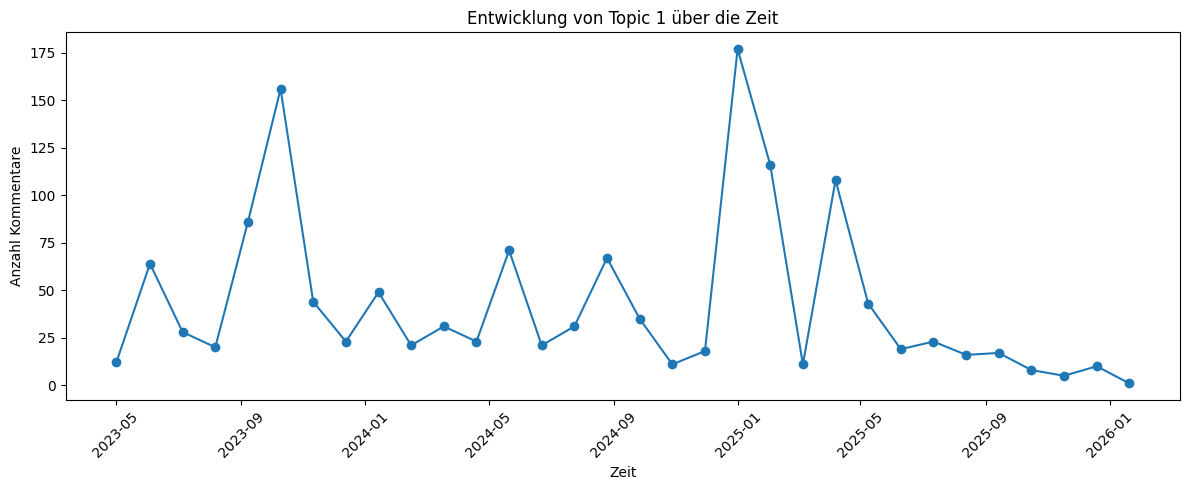

In [ ]:
import matplotlib.pyplot as plt

topic = 1

topic_time = topics_over_time[
    topics_over_time["Topic"] == topic
]

plt.figure(figsize=(12, 5))

plt.plot(
    topic_time["Timestamp"],
    topic_time["Frequency"],
    marker="o"
)

plt.title(f"Entwicklung von Topic {topic} über die Zeit")
plt.xlabel("Zeit")
plt.ylabel("Anzahl Kommentare")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Exceltabelle der Hölle

In [ ]:
import pandas as pd
import numpy as np


# ============================================================
# 1. EINSTELLUNGEN
# ============================================================

relevante_topics = [
    1, 3, 7, 9, 10, 12, 16, 17, 19, 21,
    25, 26, 28, 30, 35, 38, 40, 41, 42, 43,
    44, 45, 46, 49, 51, 52, 55, 60, 64, 65,
    67, 71
]

# >>> HIER ggf. den tatsächlichen Namen deiner Nutzer-Spalte ändern
user_col = "author"


# ============================================================
# 2. GRUNDLAGE / DATAFRAME
# ============================================================

if hasattr(comments_soldisk, "compute"):
    comments_soldisk = comments_soldisk.compute()

comments_soldisk = comments_soldisk.reset_index(drop=True)

comments_soldisk["comment_published"] = pd.to_datetime(
    comments_soldisk["comment_published"]
)

# Prüfen
assert len(textdata) == len(final_topics_jiina)
assert len(textdata) == len(comments_soldisk)

if user_col not in comments_soldisk.columns:
    raise KeyError(
        f"Die Nutzer-Spalte '{user_col}' wurde nicht gefunden.\n"
        f"Vorhandene Spalten:\n{comments_soldisk.columns.tolist()}"
    )

print("Dokumente:", len(textdata))
print("Topic-Zuordnungen:", len(final_topics_jiina))
print("Kommentare:", len(comments_soldisk))
print("Verschiedene Nutzer:", comments_soldisk[user_col].nunique())


# ============================================================
# 3. TOPIC-INFORMATIONEN
# ============================================================

topic_info = final_model_jiina.get_topic_info().copy()

topic_info_relevant = topic_info[
    topic_info["Topic"].isin(relevante_topics)
].copy()

topic_info_relevant["Topicwörter"] = (
    topic_info_relevant["Representation"]
    .apply(lambda x: ", ".join(x))
)

topic_info_relevant["Topic-Representation"] = (
    topic_info_relevant["Representation"]
    .apply(lambda x: ", ".join(x))
)

topic_info_relevant["Kommentar-Anteil_%"] = (
    topic_info_relevant["Count"]
    / len(textdata)
    * 100
)

topic_uebersicht = topic_info_relevant[
    [
        "Topic",
        "Name",
        "Topicwörter",
        "Topic-Representation",
        "Count",
        "Kommentar-Anteil_%"
    ]
].copy()

topic_uebersicht.columns = [
    "Topic-Nr",
    "Topic-Name",
    "Topicwörter",
    "Topic-Representation",
    "Anzahl Kommentare",
    "Anteil Kommentare (%)"
]

topic_uebersicht = topic_uebersicht.sort_values(
    "Topic-Nr"
)


# ============================================================
# 4. DOKUMENTEN-/VIDEO-VERTEILUNG
# ============================================================

topic_video_rows = []

gesamt_videos = comments_soldisk["video_id"].nunique()

for topic in relevante_topics:

    mask = np.array(final_topics_jiina) == topic

    topic_comments = comments_soldisk.loc[mask].copy()

    n_comments = len(topic_comments)
    n_videos = topic_comments["video_id"].nunique()

    video_counts = (
        topic_comments["video_id"]
        .value_counts()
    )

    video_anteil = (
        n_videos / gesamt_videos * 100
        if gesamt_videos > 0 else 0
    )

    durchschnitt = (
        n_comments / n_videos
        if n_videos > 0 else 0
    )

    if n_comments > 0:
        max_video_anteil = (
            video_counts.iloc[0]
            / n_comments
            * 100
        )
    else:
        max_video_anteil = 0

    topic_video_rows.append({
        "Topic-Nr": topic,
        "Anzahl Kommentare": n_comments,
        "Anzahl verschiedener Videos": n_videos,
        "Anteil aller Videos (%)": video_anteil,
        "Ø Kommentare pro Video": durchschnitt,
        "Größter Videoanteil im Topic (%)":
            max_video_anteil
    })

dokumentenverteilung = pd.DataFrame(
    topic_video_rows
)


# ============================================================
# 5. TOP-5-VIDEO-KONZENTRATION
# ============================================================

konzentration_rows = []

for topic in relevante_topics:

    mask = np.array(final_topics_jiina) == topic

    topic_comments = comments_soldisk.loc[mask]

    video_counts = (
        topic_comments["video_id"]
        .value_counts()
    )

    n_comments = len(topic_comments)

    top5_summe = video_counts.head(5).sum()

    if n_comments > 0:
        top5_anteil = (
            top5_summe
            / n_comments
            * 100
        )
    else:
        top5_anteil = 0

    konzentration_rows.append({
        "Topic-Nr": topic,
        "Top-5-Videos Kommentare": top5_summe,
        "Top-5-Videoanteil (%)": top5_anteil
    })

video_konzentration = pd.DataFrame(
    konzentration_rows
)


# ============================================================
# 6. DYNAMIC TOPIC MODELING
# ============================================================

topics_over_time = final_model_jiina.topics_over_time(
    docs=textdata,
    topics=final_topics_jiina,
    nr_bins=32,
    timestamps=comments_soldisk["comment_published"]
)

topics_over_time["Timestamp"] = pd.to_datetime(
    topics_over_time["Timestamp"],
    utc=True
).dt.tz_localize(None)


# ============================================================
# 7. GESAMTZAHL KOMMENTARE PRO ZEITFENSTER
# ============================================================

zeitfenster_gesamt = (
    topics_over_time
    .groupby("Timestamp")["Frequency"]
    .sum()
    .reset_index()
)

zeitfenster_gesamt.columns = [
    "Zeitfenster",
    "Gesamtkommentare"
]


# ============================================================
# 8. RELEVANTE TOPICS IM DYNAMIC TM
# ============================================================

dynamic_relevant = topics_over_time[
    topics_over_time["Topic"].isin(relevante_topics)
].copy()

dynamic_relevant = dynamic_relevant.rename(
    columns={
        "Topic": "Topic-Nr",
        "Timestamp": "Zeitfenster",
        "Frequency": "Häufigkeit"
    }
)

dynamic_relevant = dynamic_relevant.merge(
    zeitfenster_gesamt,
    on="Zeitfenster",
    how="left"
)

# Anteil des Topics am gesamten Korpus des Zeitfensters
dynamic_relevant["Topic-Anteil im Zeitfenster (%)"] = (
    dynamic_relevant["Häufigkeit"]
    / dynamic_relevant["Gesamtkommentare"]
    * 100
)

# Anteil dieses Zeitfensters am gesamten Topic
topic_totals = (
    dynamic_relevant
    .groupby("Topic-Nr")["Häufigkeit"]
    .sum()
    .rename("Topic_Gesamt")
)

dynamic_relevant = dynamic_relevant.merge(
    topic_totals,
    on="Topic-Nr",
    how="left"
)

dynamic_relevant["Anteil am gesamten Topic (%)"] = (
    dynamic_relevant["Häufigkeit"]
    / dynamic_relevant["Topic_Gesamt"]
    * 100
)


# ============================================================
# 9. PEAK-ANALYSE
# ============================================================

dynamic_summary_rows = []
peak_rows = []


for topic in relevante_topics:

    data = dynamic_relevant[
        dynamic_relevant["Topic-Nr"] == topic
    ].copy()

    if len(data) == 0:
        continue

    data = data.sort_values(
        "Zeitfenster"
    ).reset_index(drop=True)

    absolute_values = (
        data["Häufigkeit"]
        .astype(float)
    )

    values = (
        data["Topic-Anteil im Zeitfenster (%)"]
        .astype(float)
    )

    # --------------------------------------------------------
    # Quantile
    # --------------------------------------------------------

    q0 = values.quantile(0.00)
    q25 = values.quantile(0.25)
    q50 = values.quantile(0.50)
    q75 = values.quantile(0.75)
    q100 = values.quantile(1.00)

    q1_abs = absolute_values.quantile(0.25)
    q3_abs = absolute_values.quantile(0.75)

    iqr_abs = q3_abs - q1_abs
    iqr = q25 - q75

    peak_schwelle_abs = (
        q3_abs + 1.5 * iqr_abs
    )

    mean = values.mean()
    std = values.std()

    # Peak-Schwelle auf Basis relativer Werte
    peak_schwelle = q75 + 1.5 * iqr

    # ============================================================
    # QUARTILS-GRUPPEN MIT DESKRIPTIVEN MASSEN
    # ============================================================

    q25 = values.quantile(0.25)
    q50 = values.quantile(0.50)
    q75 = values.quantile(0.75)

    gruppe_1 = values[values <= q25]

    gruppe_2 = values[
        (values > q25) &
        (values <= q50)
    ]

    gruppe_3 = values[
        (values > q50) &
        (values <= q75)
    ]

    gruppe_4 = values[
        values > q75
    ]

    quartile_stats = {

        "0-25% Ø (%)":
            gruppe_1.mean(),

        "0-25% Median (%)":
            gruppe_1.median(),

        "0-25% Standardabw. (Prozentpunkte)":
            gruppe_1.std(),

        "25-50% Ø (%)":
            gruppe_2.mean(),

        "25-50% Median (%)":
            gruppe_2.median(),

        "25-50% Standardabw. (Prozentpunkte)":
            gruppe_2.std(),

        "50-75% Ø (%)":
            gruppe_3.mean(),

        "50-75% Median (%)":
            gruppe_3.median(),

        "50-75% Standardabw. (Prozentpunkte)":
            gruppe_3.std(),

        "75-100% Ø (%)":
            gruppe_4.mean(),

        "75-100% Median (%)":
            gruppe_4.median(),

        "75-100% Standardabw. (Prozentpunkte)":
            gruppe_4.std()
    }

    # --------------------------------------------------------
    # Aktive Zeitfenster
    # --------------------------------------------------------

    aktive_zeitfenster = (
        values > 0
    ).sum()

    # ============================================================
    # PEAKS – URSPRÜNGLICHE DEFINITION
    # ============================================================

    # ------------------------------------------------------------
    # Absolute Tukey-Schwelle
    # ------------------------------------------------------------

    q1_abs = absolute_values.quantile(0.25)
    q3_abs = absolute_values.quantile(0.75)

    iqr_abs = q3_abs - q1_abs

    peak_schwelle_abs = (
        q3_abs + 1.5 * iqr_abs
    )


    # ------------------------------------------------------------
    # Alle Zeitfenster über der Tukey-Schwelle
    # ------------------------------------------------------------

    peak_mask = (
        absolute_values > peak_schwelle_abs
    )

    peak_data_topic = data[
        peak_mask
    ].copy()


    # Anzahl Peak-Zeitfenster
    anzahl_auffaellige_peaks = len(
        peak_data_topic
    )


    # ------------------------------------------------------------
    # Peak-Daten einzeln berechnen
    # ------------------------------------------------------------

    topic_peaks = []


    for i in peak_data_topic.index:

        # Position innerhalb von data
        pos = data.index.get_loc(i)

        current_abs = absolute_values.loc[i]

        # -----------------------------------------
        # Relative Anteile
        # -----------------------------------------

        peak_share_topic = (
            current_abs
            / absolute_values.sum()
            * 100
        )

        peak_share_corpus = (
            data.loc[
                i,
                "Topic-Anteil im Zeitfenster (%)"
            ]
        )

        # -----------------------------------------
        # Median-Verhältnis
        # -----------------------------------------

        peak_vs_median = (
            current_abs
            / absolute_values.median()
            if absolute_values.median() > 0
            else np.nan
        )

        # -----------------------------------------
        # Anstieg / Abfall
        #
        # Nur wenn Nachbar-Zeitfenster existieren
        # -----------------------------------------

        if pos > 0:

            previous_abs = (
                absolute_values.iloc[pos - 1]
            )

            increase_abs = (
                current_abs
                - previous_abs
            )

            if previous_abs > 0:

                increase_pct = (
                    increase_abs
                    / previous_abs
                    * 100
                )

            else:

                increase_pct = np.nan

            increase_windows = 1

        else:

            increase_abs = np.nan
            increase_pct = np.nan
            increase_windows = np.nan


        if pos < len(data) - 1:

            following_abs = (
                absolute_values.iloc[pos + 1]
            )

            decrease_abs = (
                current_abs
                - following_abs
            )

            if current_abs > 0:

                decrease_pct = (
                    decrease_abs
                    / current_abs
                    * 100
                )

            else:

                decrease_pct = np.nan

            decrease_windows = 1

        else:

            decrease_abs = np.nan
            decrease_pct = np.nan
            decrease_windows = np.nan


        # -----------------------------------------
        # Peak speichern
        # -----------------------------------------

        topic_peaks.append({

            "Topic-Nr": topic,

            "Peak-Zeitfenster":
                data.loc[
                    i,
                    "Zeitfenster"
                ],

            "Peak-Häufigkeit":
                current_abs,

            "Peak-Anteil am Korpus (%)":
                peak_share_corpus,

            "Peak-Anteil am Topic (%)":
                peak_share_topic,

            "Peak / Median":
                peak_vs_median,

            "Auffälliger Peak (Tukey)":
                True,

            "Tukey-Schwelle":
                peak_schwelle_abs,

            "Q1 absolute":
                q1_abs,

            "Q3 absolute":
                q3_abs,

            "IQR absolute":
                iqr_abs,

            "Anstieg relativ (%)":
                increase_pct,

            "Anstieg absolut":
                increase_abs,

            "Anstiegsdauer (Zeitfenster)":
                increase_windows,

            "Abfall relativ (%)":
                decrease_pct,

            "Abfall absolut":
                decrease_abs,

            "Abfalldauer (Zeitfenster)":
                decrease_windows
        })


    # ============================================================
    # PEAKS NACH STÄRKE SORTIEREN
    # ============================================================

    topic_peaks = sorted(
        topic_peaks,
        key=lambda x: x[
            "Peak-Anteil am Korpus (%)"
        ],
        reverse=True
    )


    # Rang vergeben
    for rank, row in enumerate(
        topic_peaks,
        start=1
    ):

        row["Peak-Rang"] = rank


    # ============================================================
    # ALLE PEAKS SPEICHERN
    # ============================================================

    peak_rows.extend(
        topic_peaks
    )


    # ============================================================
    # TOP 3 NUR FÜR ZUSAMMENFASSUNG
    # ============================================================

    topic_peaks_top3 = (
        topic_peaks[:3]
    )


    # ============================================================
    # STÄRKSTER PEAK
    # ============================================================

    if topic_peaks:

        strongest = topic_peaks[0]

        peak1_time = (
            strongest["Peak-Zeitfenster"]
        )

        peak1_corpus = (
            strongest[
                "Peak-Anteil am Korpus (%)"
            ]
        )

        peak1_topic = (
            strongest[
                "Peak-Anteil am Topic (%)"
            ]
        )

    else:

        peak1_time = pd.NaT
        peak1_corpus = np.nan
        peak1_topic = np.nan


    # ============================================================
    # TOP-3-KONZENTRATION
    # ============================================================

    top3_share = sum(
        x["Peak-Anteil am Topic (%)"]
        for x in topic_peaks_top3
    )
    # --------------------------------------------------------
    # Zusammenfassung
    # --------------------------------------------------------

    dynamic_summary_rows.append({

        "Topic-Nr": topic,

        # Gesamtverteilung
        "Minimum Anteil (%)": values.min(),
        "Mittelwert Anteil (%)": values.mean(),
        "Median Anteil (%)": values.median(),
        "Maximum Anteil (%)": values.max(),
        "Standardabweichung (Prozentpunkte)": values.std(),
        "IQR (Prozentpunkte)": q75 - q25,

        # 0–25 %
        "0-25% Zeitfenster": len(gruppe_1),
        "0-25% Mittelwert (%)": gruppe_1.mean(),
        "0-25% Median (%)": gruppe_1.median(),
        "0-25% Standardabweichung (Prozentpunkte)": gruppe_1.std(),

        # 25–50 %
        "25-50% Zeitfenster": len(gruppe_2),
        "25-50% Mittelwert (%)": gruppe_2.mean(),
        "25-50% Median (%)": gruppe_2.median(),
        "25-50% Standardabweichung (Prozentpunkte)": gruppe_2.std(),

        # 50–75 %
        "50-75% Zeitfenster": len(gruppe_3),
        "50-75% Mittelwert (%)": gruppe_3.mean(),
        "50-75% Median (%)": gruppe_3.median(),
        "50-75% Standardabweichung (Prozentpunkte)": gruppe_3.std(),

        # 75–100 %
        "75-100% Zeitfenster": len(gruppe_4),
        "75-100% Mittelwert (%)": gruppe_4.mean(),
        "75-100% Median (%)": gruppe_4.median(),
        "75-100% Standardabweichung (Prozentpunkte)": gruppe_4.std(),

        # Zeitliche Präsenz
        "Aktive Zeitfenster": aktive_zeitfenster,
        "Anteil aktive Zeitfenster (%)":
            aktive_zeitfenster / len(data) * 100,

        # Peaks
        "Anzahl Peaks": len(topic_peaks),
        "Anzahl auffällige Peaks (Tukey)": anzahl_auffaellige_peaks,
        "Tukey-Schwelle absolute": peak_schwelle_abs,
        "Stärkster Peak – Zeitfenster": peak1_time,
        "Stärkster Peak – Korpus (%)": peak1_corpus,
        "Stärkster Peak – Topic (%)": peak1_topic,
        "Stärkster Peak / Median":
            (
                peak1_corpus / values.median()
                if values.median() > 0
                else np.nan
            ),
        "Top-3-Peaks – Topic (%)": top3_share
    })

dynamic_summary = pd.DataFrame(
    dynamic_summary_rows
)

peak_data = pd.DataFrame(
    peak_rows
)

# ============================================================
# 10. GESAMTSTATISTIK DES GESAMTEN MODELLS
# ============================================================

# Alle Topics des Modells pro Zeitfenster
gesamtverlauf = (
    topics_over_time
    .groupby("Timestamp", as_index=False)["Frequency"]
    .sum()
    .sort_values("Timestamp")
    .reset_index(drop=True)
)

gesamtverlauf = gesamtverlauf.rename(
    columns={
        "Timestamp": "Zeitfenster",
        "Frequency": "Gesamtkommentare"
    }
)

# Anteil jedes Zeitfensters am gesamten Modell
gesamt_modell = (
    gesamtverlauf["Gesamtkommentare"].sum()
)

gesamtverlauf["Anteil am Gesamtkorpus (%)"] = (
    gesamtverlauf["Gesamtkommentare"]
    / gesamt_modell
    * 100
)

gesamt_values = (
    gesamtverlauf[
        "Anteil am Gesamtkorpus (%)"
    ]
    .astype(float)
)

gesamt_q0 = gesamt_values.quantile(0.00)
gesamt_q25 = gesamt_values.quantile(0.25)
gesamt_q50 = gesamt_values.quantile(0.50)
gesamt_q75 = gesamt_values.quantile(0.75)
gesamt_q100 = gesamt_values.quantile(1.00)

gesamt_statistik = pd.DataFrame([{

    "Minimum Anteil (%)":
        gesamt_q0,

    "P25 (%)":
        gesamt_q25,

    "P50 Median (%)":
        gesamt_q50,

    "P75 (%)":
        gesamt_q75,

    "Maximum Anteil (%)":
        gesamt_q100,

    "Quartil 1: 0-25%":
        f"{gesamt_q0:.3f}% – {gesamt_q25:.3f}%",

    "Quartil 2: 25-50%":
        f"{gesamt_q25:.3f}% – {gesamt_q50:.3f}%",

    "Quartil 3: 50-75%":
        f"{gesamt_q50:.3f}% – {gesamt_q75:.3f}%",

    "Quartil 4: 75-100%":
        f"{gesamt_q75:.3f}% – {gesamt_q100:.3f}%",

    "Mittelwert Anteil (%)":
        gesamt_values.mean(),

    "Standardabweichung (Prozentpunkte)":
        gesamt_values.std(),

    "IQR (Prozentpunkte)":
        gesamt_q75 - gesamt_q25
}])




Dokumente: 45733
Topic-Zuordnungen: 45733
Kommentare: 45733
Verschiedene Nutzer: 22674


32it [00:09,  3.44it/s]


In [ ]:
# ============================================================
# 10. NUTZERANALYSE PRO TOPIC
# ============================================================


if user_col not in comments_soldisk.columns:
    raise KeyError(
        f"Die Nutzer-Spalte '{user_col}' wurde nicht gefunden.\n"
        f"Vorhandene Spalten:\n{comments_soldisk.columns.tolist()}"
    )


# ------------------------------------------------------------
# 10.1 Gesamtzahl Nutzer im Korpus
# ------------------------------------------------------------

gesamt_nutzer = comments_soldisk[user_col].nunique()


topic_user_rows = []

for topic in relevante_topics:

    mask = np.array(final_topics_jiina) == topic

    topic_comments = comments_soldisk.loc[mask].copy()

    n_comments = len(topic_comments)

    # Nutzer entfernen, sofern fehlend
    topic_comments_valid = topic_comments[
        topic_comments[user_col].notna()
    ].copy()

    n_users = topic_comments_valid[user_col].nunique()

    # Anteil Nutzer des Topics an allen Nutzern
    user_share_corpus = (
        n_users / gesamt_nutzer * 100
        if gesamt_nutzer > 0 else 0
    )

    # Kommentare pro Nutzer
    user_counts = (
        topic_comments_valid[user_col]
        .value_counts()
    )

    mean_comments_user = (
        n_comments / n_users
        if n_users > 0 else 0
    )

    median_comments_user = (
        user_counts.median()
        if len(user_counts) > 0 else np.nan
    )

    # Konzentration
    top1_comments = (
        user_counts.head(1).sum()
    )

    top5_comments = (
        user_counts.head(5).sum()
    )

    top10_comments = (
        user_counts.head(10).sum()
    )

    top1_share = (
        top1_comments / n_comments * 100
        if n_comments > 0 else 0
    )

    top5_share = (
        top5_comments / n_comments * 100
        if n_comments > 0 else 0
    )

    top10_share = (
        top10_comments / n_comments * 100
        if n_comments > 0 else 0
    )

    topic_user_rows.append({

        "Topic-Nr": topic,

        "Anzahl Kommentare":
            n_comments,

        "Verschiedene Nutzer":
            n_users,

        "Anteil Nutzer am Gesamtkorpus (%)":
            user_share_corpus,

        "Ø Kommentare pro Nutzer":
            mean_comments_user,

        "Median Kommentare pro Nutzer":
            median_comments_user,

        "Top-1-Nutzer Kommentare":
            top1_comments,

        "Top-1-Nutzer Anteil (%)":
            top1_share,

        "Top-5-Nutzer Kommentare":
            top5_comments,

        "Top-5-Nutzer Anteil (%)":
            top5_share,

        "Top-10-Nutzer Kommentare":
            top10_comments,

        "Top-10-Nutzer Anteil (%)":
            top10_share
    })


topic_nutzer = pd.DataFrame(topic_user_rows)


# ============================================================
# 11. NUTZER ÜBER DIE ZEIT
# ============================================================

# Wir verwenden dieselben 32 gleich großen Zeitintervalle
# wie beim Dynamic Topic Modeling.

start_date = comments_soldisk["comment_published"].min()
end_date = comments_soldisk["comment_published"].max()

bin_edges = pd.date_range(
    start=start_date,
    end=end_date,
    periods=33
)

# Zeitfenster für jeden Kommentar bestimmen
comments_time = comments_soldisk.copy()

comments_time["comment_published"] = pd.to_datetime(
    comments_time["comment_published"],
    utc=True
).dt.tz_localize(None)

start_date = comments_time["comment_published"].min()
end_date = comments_time["comment_published"].max()

bin_edges = pd.date_range(
    start=start_date,
    end=end_date,
    periods=33
)

comments_time["Zeitfenster"] = pd.cut(
    comments_time["comment_published"],
    bins=bin_edges,
    include_lowest=True,
    duplicates="drop"
)


# ------------------------------------------------------------
# Nutzer pro Topic und Zeitfenster
# ------------------------------------------------------------

topic_user_time_rows = []


for topic in relevante_topics:

    topic_mask = (
        np.array(final_topics_jiina) == topic
    )

    topic_comments = comments_time.loc[
        topic_mask
    ].copy()

    for time_bin, group in topic_comments.groupby(
        "Zeitfenster",
        observed=False
    ):

        valid_users = group[
            group[user_col].notna()
        ][user_col]

        n_users = valid_users.nunique()

        n_comments = len(group)

        topic_user_time_rows.append({

            "Topic-Nr": topic,

            "Zeitfenster":
                str(time_bin),

            "Verschiedene Nutzer":
                n_users,

            "Kommentare":
                n_comments
        })


topic_nutzer_zeit = pd.DataFrame(
    topic_user_time_rows
)


# ------------------------------------------------------------
# Anteil der Nutzer des Topics im jeweiligen Zeitfenster
#
# Bezugsgröße:
# alle unterschiedlichen Nutzer des Topics
# ------------------------------------------------------------

topic_user_totals = (
    topic_nutzer
    .set_index("Topic-Nr")["Verschiedene Nutzer"]
)

topic_nutzer_zeit["Topic_Gesamtnutzer"] = (
    topic_nutzer_zeit["Topic-Nr"]
    .map(topic_user_totals)
)

topic_nutzer_zeit["Nutzeranteil innerhalb Topic (%)"] = (
    topic_nutzer_zeit["Verschiedene Nutzer"]
    / topic_nutzer_zeit["Topic_Gesamtnutzer"]
    * 100
)


# ------------------------------------------------------------
# Nutzeranteil am gesamten Nutzerbestand
# ------------------------------------------------------------

topic_nutzer_zeit["Nutzeranteil am Korpus (%)"] = (
    topic_nutzer_zeit["Verschiedene Nutzer"]
    / gesamt_nutzer
    * 100
)


# ============================================================
# 12. NUTZER IN PEAKS
# ============================================================

topic_nutzer_peak_rows = []


if not peak_data.empty:

    for _, peak in peak_data.iterrows():

        topic = peak["Topic-Nr"]

        # Peak-Zeitfenster
        peak_time = pd.Timestamp(
            peak["Peak-Zeitfenster"]
        )

        # Für den Peak verwenden wir das entsprechende
        # Dynamic-TM-Zeitfenster.
        #
        # Wir suchen das Zeitfenster, dessen Mittelpunkt
        # dem BERTopic-Timestamp am nächsten liegt.

        topic_mask = (
            np.array(final_topics_jiina) == topic
        )

        topic_comments = comments_time.loc[
            topic_mask
        ].copy()

        # Falls keine Daten vorhanden sind
        if topic_comments.empty:
            continue

        # Alle Kommentare im entsprechenden Zeit-Bin
        matching_groups = topic_comments[
            topic_comments["Zeitfenster"].apply(
                lambda x:
                x.left <= peak_time <= x.right
                if pd.notna(x)
                else False
            )
        ]

        valid_users = matching_groups[
            matching_groups[user_col].notna()
        ][user_col]

        n_peak_users = valid_users.nunique()

        n_peak_comments = len(
            matching_groups
        )

        # Gesamtzahl Nutzer/Kommentare im Topic
        total_topic_users = topic_comments[
            topic_comments[user_col].notna()
        ][user_col].nunique()

        total_topic_comments = len(
            topic_comments
        )

        topic_nutzer_peak_rows.append({

            "Topic-Nr":
                topic,

            "Peak-Rang":
                peak.get(
                    "Peak-Rang",
                    np.nan
                ),

            "Peak-Zeitfenster":
                peak["Peak-Zeitfenster"],

            "Peak-Kommentare":
                n_peak_comments,

            "Peak-Nutzer":
                n_peak_users,

            "Peak-Nutzeranteil am Topic (%)":
                (
                    n_peak_users
                    / total_topic_users
                    * 100
                    if total_topic_users > 0
                    else 0
                ),

            "Peak-Nutzeranteil am Gesamtkorpus (%)":
                (
                    n_peak_users
                    / gesamt_nutzer
                    * 100
                    if gesamt_nutzer > 0
                    else 0
                ),

            "Peak-Kommentaranteil am Topic (%)":
                (
                    n_peak_comments
                    / total_topic_comments
                    * 100
                    if total_topic_comments > 0
                    else 0
                ),

            "Kommentare pro Peak-Nutzer":
                (
                    n_peak_comments
                    / n_peak_users
                    if n_peak_users > 0
                    else 0
                )
        })


topic_nutzer_peaks = pd.DataFrame(
    topic_nutzer_peak_rows
)


# ============================================================
# 13. RUNDEN
# ============================================================

for df in [
    topic_nutzer,
    topic_nutzer_zeit,
    topic_nutzer_peaks
]:

    for col in df.select_dtypes(
        include=["float64", "float32"]
    ).columns:

        df[col] = df[col].round(3)


gesamt = (
    topic_uebersicht
    .merge(
        dokumentenverteilung,
        on="Topic-Nr",
        how="left"
    )
    .merge(
        video_konzentration,
        on="Topic-Nr",
        how="left"
    )
    .merge(
        dynamic_summary,
        on="Topic-Nr",
        how="left"
    )
)

# ============================================================
# 14. EXCEL EXPORT
# ============================================================

dateiname = "JIINA_DATA_FINAL.xlsx"

with pd.ExcelWriter(
    dateiname,
    engine="openpyxl"
) as writer:

    # Bereits vorhandene Tabellen
    gesamt.to_excel(
        writer,
        sheet_name="Gesamtübersicht",
        index=False
    )

    topic_uebersicht.to_excel(
        writer,
        sheet_name="Topic-Infos",
        index=False
    )

    dokumentenverteilung.to_excel(
        writer,
        sheet_name="Dokumentenverteilung",
        index=False
    )

    video_konzentration.to_excel(
        writer,
        sheet_name="Video-Konzentration",
        index=False
    )

    dynamic_relevant.to_excel(
        writer,
        sheet_name="Dynamic-TM",
        index=False
    )

    dynamic_summary.to_excel(
        writer,
        sheet_name="Dynamic-Zusammenfassung",
        index=False
    )

    peak_data.to_excel(
        writer,
        sheet_name="Peak-Analyse",
        index=False
    )

    gesamtverlauf.to_excel(
        writer,
        sheet_name="Gesamtstatistik",
        index=False
    )

    gesamt_statistik.to_excel(
        writer,
        sheet_name="Gesamtstatistik_Summary",
        index=False
    )

    # Neue Nutzer-Sheets
    topic_nutzer.to_excel(
        writer,
        sheet_name="Topic_Nutzer",
        index=False
    )

    topic_nutzer_zeit.to_excel(
        writer,
        sheet_name="Topic_Nutzer_Zeit",
        index=False
    )

    topic_nutzer_peaks.to_excel(
        writer,
        sheet_name="Topic_Nutzer_Peaks",
        index=False
    )


print(
    f"Excel-Datei erfolgreich erweitert:\n{dateiname}"
)

Excel-Datei erfolgreich erweitert:
JIINA_DATA_FINAL.xlsx


In [ ]:
import pandas as pd
import numpy as np


# ============================================================
# NEUE PEAK-ANALYSE: ALLE LOKALEN PEAKS
# ============================================================

peak_all_rows = []


for topic in relevante_topics:

    data = dynamic_relevant[
        dynamic_relevant["Topic-Nr"] == topic
    ].copy()

    if len(data) < 3:
        continue

    data = data.sort_values(
        "Zeitfenster"
    ).reset_index(drop=True)


    # ========================================================
    # ABSOLUTE HÄUFIGKEIT
    # ========================================================

    absolute_values = (
        data["Häufigkeit"]
        .astype(float)
    )


    # ========================================================
    # RELATIVE HÄUFIGKEIT
    # ========================================================

    relative_values = (
        data["Topic-Anteil im Zeitfenster (%)"]
        .astype(float)
    )


    # ========================================================
    # TUKEY-KENNWERTE
    # ========================================================

    q1_abs = absolute_values.quantile(0.25)
    q3_abs = absolute_values.quantile(0.75)

    iqr_abs = (
        q3_abs - q1_abs
    )

    tukey_threshold = (
        q3_abs
        + 1.5 * iqr_abs
    )


    # ========================================================
    # LOKALE PEAKS ERMITTELN
    #
    # Wichtig:
    # ALLE lokalen Peaks werden gespeichert.
    # Tukey dient nur als zusätzliche Kennzeichnung.
    # ========================================================

    topic_peaks = []


    for i in range(
        1,
        len(data) - 1
    ):

        current = (
            absolute_values.iloc[i]
        )

        previous = (
            absolute_values.iloc[i - 1]
        )

        following = (
            absolute_values.iloc[i + 1]
        )


        # ----------------------------------------------------
        # Lokales Maximum?
        # ----------------------------------------------------

        if not (
            current > previous
            and current >= following
        ):
            continue


        # ----------------------------------------------------
        # Tukey-Status
        # ----------------------------------------------------

        tukey_peak = (
            current > tukey_threshold
        )


        # ====================================================
        # LINKES LOKALES MINIMUM
        # ====================================================

        left = i - 1

        while left > 0:

            if (
                absolute_values.iloc[left - 1]
                >= absolute_values.iloc[left]
            ):
                break

            left -= 1


        # ====================================================
        # RECHTES LOKALES MINIMUM
        # ====================================================

        right = i + 1

        while (
            right
            < len(data) - 1
        ):

            if (
                absolute_values.iloc[right + 1]
                >= absolute_values.iloc[right]
            ):
                break

            right += 1


        # ====================================================
        # WERTE
        # ====================================================

        start_abs = (
            absolute_values.iloc[left]
        )

        peak_abs = current

        end_abs = (
            absolute_values.iloc[right]
        )


        start_relative = (
            relative_values.iloc[left]
        )

        peak_relative = (
            relative_values.iloc[i]
        )

        end_relative = (
            relative_values.iloc[right]
        )


        # ====================================================
        # ANSTIEG
        # ====================================================

        increase_abs = (
            peak_abs - start_abs
        )

        if start_abs > 0:

            increase_pct = (
                increase_abs
                / start_abs
                * 100
            )

        else:

            increase_pct = np.nan


        increase_windows = (
            i - left
        )


        # ====================================================
        # ABFALL
        # ====================================================

        decrease_abs = (
            peak_abs - end_abs
        )

        if peak_abs > 0:

            decrease_pct = (
                decrease_abs
                / peak_abs
                * 100
            )

        else:

            decrease_pct = np.nan


        decrease_windows = (
            right - i
        )


        # ====================================================
        # PEAK-ANTEILE
        # ====================================================

        topic_total = (
            absolute_values.sum()
        )

        peak_share_topic = (
            peak_abs
            / topic_total
            * 100
            if topic_total > 0
            else np.nan
        )


        # Peak-Anteil am Korpus
        peak_share_corpus = (
            peak_relative
        )


        # ====================================================
        # PEAK / MEDIAN
        # ====================================================

        median_abs = (
            absolute_values.median()
        )

        peak_vs_median = (
            peak_abs / median_abs
            if median_abs > 0
            else np.nan
        )


        # ====================================================
        # PEAK-BREITE ÜBER TUKEY-SCHWELLE
        #
        # Nur zur Beschreibung der auffälligen Phase.
        # Alle Peaks werden trotzdem gespeichert.
        # ====================================================

        peak_left = i

        while (
            peak_left > 0
            and absolute_values.iloc[
                peak_left - 1
            ] > tukey_threshold
        ):
            peak_left -= 1


        peak_right = i

        while (
            peak_right
            < len(data) - 1
            and absolute_values.iloc[
                peak_right + 1
            ] > tukey_threshold
        ):
            peak_right += 1


        peak_width = (
            peak_right
            - peak_left
            + 1
        )


        # ====================================================
        # PEAK SPEICHERN
        # ====================================================

        topic_peaks.append({

            "Topic-Nr":
                topic,

            "Peak-Zeitfenster":
                data.loc[
                    i,
                    "Zeitfenster"
                ],

            "Start-Zeitfenster":
                data.loc[
                    left,
                    "Zeitfenster"
                ],

            "End-Zeitfenster":
                data.loc[
                    right,
                    "Zeitfenster"
                ],

            # ----------------------------------------------
            # Absolute Werte
            # ----------------------------------------------

            "Start-Häufigkeit":
                start_abs,

            "Peak-Häufigkeit":
                peak_abs,

            "End-Häufigkeit":
                end_abs,

            # ----------------------------------------------
            # Relative Werte
            # ----------------------------------------------

            "Start-Anteil Korpus (%)":
                start_relative,

            "Peak-Anteil Korpus (%)":
                peak_share_corpus,

            "End-Anteil Korpus (%)":
                end_relative,

            "Peak-Anteil Topic (%)":
                peak_share_topic,

            # ----------------------------------------------
            # Peak-Stärke
            # ----------------------------------------------

            "Peak / Median":
                peak_vs_median,

            # ----------------------------------------------
            # Anstieg
            # ----------------------------------------------

            "Anstieg absolut":
                increase_abs,

            "Anstieg relativ (%)":
                increase_pct,

            "Anstiegsdauer (Zeitfenster)":
                increase_windows,

            # ----------------------------------------------
            # Abfall
            # ----------------------------------------------

            "Abfall absolut":
                decrease_abs,

            "Abfall relativ (%)":
                decrease_pct,

            "Abfalldauer (Zeitfenster)":
                decrease_windows,

            # ----------------------------------------------
            # Tukey
            # ----------------------------------------------

            "Auffälliger Peak (Tukey)":
                tukey_peak,

            "Q1 absolute":
                q1_abs,

            "Q3 absolute":
                q3_abs,

            "IQR absolute":
                iqr_abs,

            "Tukey-Schwelle absolute":
                tukey_threshold,

            # ----------------------------------------------
            # Peak-Breite
            # ----------------------------------------------

            "Peak-Breite über Tukey-Schwelle":
                peak_width
        })


    # ========================================================
    # PEAKS NACH STÄRKE SORTIEREN
    # ========================================================

    topic_peaks = sorted(
        topic_peaks,
        key=lambda x: x[
            "Peak-Häufigkeit"
        ],
        reverse=True
    )


    # ========================================================
    # RANG INNERHALB DES TOPICS
    # ========================================================

    for rank, row in enumerate(
        topic_peaks,
        start=1
    ):

        row["Peak-Rang"] = rank


    # ========================================================
    # IN GESAMTLISTE ÜBERNEHMEN
    # ========================================================

    peak_all_rows.extend(
        topic_peaks
    )


# ============================================================
# DATAFRAME
# ============================================================

peak_alle = pd.DataFrame(
    peak_all_rows
)


# ============================================================
# SORTIEREN
# ============================================================

peak_alle = peak_alle.sort_values(
    [
        "Topic-Nr",
        "Peak-Rang"
    ]
).reset_index(drop=True)


# ============================================================
# RUNDEN
# ============================================================

for col in peak_alle.select_dtypes(
    include=["float64", "float32"]
).columns:

    peak_alle[col] = (
        peak_alle[col].round(3)
    )


# ============================================================
# KONTROLLE
# ============================================================

print(
    "Anzahl aller lokalen Peaks:",
    len(peak_alle)
)

print(
    "\nPeaks pro Topic:"
)

print(
    peak_alle[
        "Topic-Nr"
    ].value_counts().sort_index()
)

print(
    "\nTukey-auffällige Peaks:"
)

print(
    peak_alle[
        "Auffälliger Peak (Tukey)"
    ].value_counts()
)


# ============================================================
# NEUE EXCEL-DATEI
# ============================================================

neue_datei = (
    "JIINA_Peak_Analyse_FINAL.xlsx"
)


with pd.ExcelWriter(
    neue_datei,
    engine="openpyxl"
) as writer:

    # --------------------------------------------------------
    # ALLE PEAKS
    # --------------------------------------------------------

    peak_alle.to_excel(
        writer,
        sheet_name="Alle_Peaks",
        index=False
    )


    # --------------------------------------------------------
    # NUR TUKEY-AUFFÄLLIGE PEAKS
    # --------------------------------------------------------

    peak_tukey = peak_alle[
        peak_alle[
            "Auffälliger Peak (Tukey)"
        ]
    ].copy()

    peak_tukey.to_excel(
        writer,
        sheet_name="Tukey_Peaks",
        index=False
    )


    # --------------------------------------------------------
    # TOP 3 JE TOPIC
    # --------------------------------------------------------

    peak_top3 = (
        peak_alle
        .groupby("Topic-Nr")
        .head(3)
        .copy()
    )

    peak_top3.to_excel(
        writer,
        sheet_name="Top3_Peaks",
        index=False
    )


print(
    f"\nNeue Excel-Datei erstellt: {neue_datei}"
)

Anzahl aller lokalen Peaks: 237

Peaks pro Topic:
Topic-Nr
1     11
3      9
7      9
9      9
10     8
12     9
16     9
17     8
19     8
21     9
25    10
26    11
28    10
30     8
35     5
38     9
40     8
41     8
42     7
43     7
44     6
45     7
46     5
49     8
51     7
52     7
55     5
60     4
65     5
67     5
71     6
Name: count, dtype: int64

Tukey-auffällige Peaks:
Auffälliger Peak (Tukey)
False    188
True      49
Name: count, dtype: int64

Neue Excel-Datei erstellt: JIINA_Peak_Analyse_FINAL.xlsx


In [ ]:
import pandas as pd
import numpy as np


# ============================================================
# EINSTELLUNGEN
# ============================================================

user_col = "author"

relevante_topics = [
    1, 3, 7, 9, 10, 12, 16, 17, 19, 21,
    25, 26, 28, 30, 35, 38, 40, 41, 42, 43,
    44, 45, 46, 49, 51, 52, 55, 60, 64, 65,
    67, 71
]


# ============================================================
# GRUNDLAGE
# ============================================================

if hasattr(comments_soldisk, "compute"):
    comments_soldisk = comments_soldisk.compute()

comments_soldisk = comments_soldisk.reset_index(drop=True)

if user_col not in comments_soldisk.columns:
    raise KeyError(
        f"Spalte '{user_col}' nicht gefunden."
    )

topics_array = np.array(final_topics_jiina)

gesamt_nutzer = (
    comments_soldisk[user_col]
    .dropna()
    .nunique()
)


# ============================================================
# GINI-FUNKTION
# ============================================================

def gini(x):
    total = 0
    for i, xi in enumerate(x[:-1], 1):
        total += np.sum(np.abs(xi - x[i:]))
    return total / (len(x)**2 * np.mean(x))


# ============================================================
# ANALYSE
# ============================================================

rows = []

for topic in relevante_topics:

    mask = topics_array == topic

    topic_comments = comments_soldisk.loc[
        mask
    ].copy()

    # Nur Kommentare mit bekanntem Nutzer
    topic_comments = topic_comments[
        topic_comments[user_col].notna()
    ].copy()

    if topic_comments.empty:
        continue

    # --------------------------------------------------------
    # Kommentare je Nutzer
    # --------------------------------------------------------

    user_counts = (
        topic_comments[user_col]
        .value_counts()
        .sort_values(ascending=False)
    )

    n_comments = len(topic_comments)

    n_users = len(user_counts)

    # --------------------------------------------------------
    # Grundwerte
    # --------------------------------------------------------

    mean_comments = user_counts.mean()

    median_comments = user_counts.median()

    std_comments = user_counts.std()

    min_comments = user_counts.min()

    max_comments = user_counts.max()

    # --------------------------------------------------------
    # Quantile
    # --------------------------------------------------------

    p25 = user_counts.quantile(0.25)
    p50 = user_counts.quantile(0.50)
    p75 = user_counts.quantile(0.75)
    p90 = user_counts.quantile(0.90)
    p95 = user_counts.quantile(0.95)

    # --------------------------------------------------------
    # Konzentration
    # --------------------------------------------------------

    top1_comments = (
        user_counts.head(1).sum()
    )

    top5_comments = (
        user_counts.head(5).sum()
    )

    top10_comments = (
        user_counts.head(10).sum()
    )

    top1_share = (
        top1_comments
        / n_comments
        * 100
    )

    top5_share = (
        top5_comments
        / n_comments
        * 100
    )

    top10_share = (
        top10_comments
        / n_comments
        * 100
    )

    # --------------------------------------------------------
    # Nutzer mit genau 1 Kommentar
    # --------------------------------------------------------

    one_comment_users = (
        (user_counts == 1)
        .sum()
    )

    one_comment_user_share = (
        one_comment_users
        / n_users
        * 100
    )

    # --------------------------------------------------------
    # Nutzer mit <= 2 / <= 5 Kommentaren
    # --------------------------------------------------------

    two_or_less = (
        (user_counts <= 2)
        .sum()
        / n_users
        * 100
    )

    five_or_less = (
        (user_counts <= 5)
        .sum()
        / n_users
        * 100
    )

    # --------------------------------------------------------
    # Nutzer, die >= 10 Kommentare schreiben
    # --------------------------------------------------------

    ten_plus_users = (
        (user_counts >= 10)
        .sum()
    )

    ten_plus_share_users = (
        ten_plus_users
        / n_users
        * 100
    )

    ten_plus_comments = (
        user_counts[
            user_counts >= 10
        ].sum()
    )

    ten_plus_comment_share = (
        ten_plus_comments
        / n_comments
        * 100
    )

    # --------------------------------------------------------
    # Gini
    # --------------------------------------------------------


    gini_value_user = gini(
        user_counts.to_numpy()
    )

    # --------------------------------------------------------
    # Anteil Nutzer am Gesamtkorpus
    # --------------------------------------------------------

    user_share_corpus = (
        n_users
        / gesamt_nutzer
        * 100
        if gesamt_nutzer > 0
        else 0
    )

    # --------------------------------------------------------
    # Wie viele Nutzer erzeugen 50 % der Kommentare?
    # --------------------------------------------------------

    cumulative_comments = (
        user_counts.cumsum()
    )

    half_comments = (
        n_comments * 0.50
    )

    users_for_50_percent = (
        np.searchsorted(
            cumulative_comments.values,
            half_comments,
            side="left"
        ) + 1
    )

    users_for_50_percent_share = (
        users_for_50_percent
        / n_users
        * 100
    )

    # --------------------------------------------------------
    # Top-Nutzer bestimmen
    # --------------------------------------------------------

    top_user = user_counts.index[0]

    top_user_comments = user_counts.iloc[0]

    # --------------------------------------------------------
    # Ergebnis
    # --------------------------------------------------------

    rows.append({

        "Topic-Nr":
            topic,

        "Kommentare":
            n_comments,

        "Verschiedene Nutzer":
            n_users,

        "Anteil Nutzer am Gesamtkorpus (%)":
            user_share_corpus,

        # Verteilung
        "Ø Kommentare pro Nutzer":
            mean_comments,

        "Median Kommentare pro Nutzer":
            median_comments,

        "Standardabweichung Kommentare pro Nutzer":
            std_comments,

        "Minimum Kommentare pro Nutzer":
            min_comments,

        "Maximum Kommentare pro Nutzer":
            max_comments,

        "P25 Kommentare pro Nutzer":
            p25,

        "P50 Kommentare pro Nutzer":
            p50,

        "P75 Kommentare pro Nutzer":
            p75,

        "P90 Kommentare pro Nutzer":
            p90,

        "P95 Kommentare pro Nutzer":
            p95,

        # Konzentration
        "Top-1-Nutzer Kommentare":
            top1_comments,

        "Top-1-Nutzer Anteil (%)":
            top1_share,

        "Top-5-Nutzer Kommentare":
            top5_comments,

        "Top-5-Nutzer Anteil (%)":
            top5_share,

        "Top-10-Nutzer Kommentare":
            top10_comments,

        "Top-10-Nutzer Anteil (%)":
            top10_share,

        # Einmalige / hochaktive Nutzer
        "Nutzer mit genau 1 Kommentar":
            one_comment_users,

        "Anteil Nutzer mit genau 1 Kommentar (%)":
            one_comment_user_share,

        "Anteil Nutzer mit <=2 Kommentaren (%)":
            two_or_less,

        "Anteil Nutzer mit <=5 Kommentaren (%)":
            five_or_less,

        "Nutzer mit >=10 Kommentaren":
            ten_plus_users,

        "Anteil Nutzer mit >=10 Kommentaren (%)":
            ten_plus_share_users,

        "Kommentaranteil von Nutzern >=10 Kommentare (%)":
            ten_plus_comment_share,

        # Ungleichheit
        "Gini Nutzerkommentare":
            gini_value_user,

        # Konzentration bis 50%
        "Nutzer für 50% der Kommentare":
            users_for_50_percent,

        "Anteil Nutzer für 50% der Kommentare (%)":
            users_for_50_percent_share,

        # stärkster Nutzer
        "Aktivster Nutzer":
            top_user,

        "Kommentare aktivster Nutzer":
            top_user_comments
    })


nutzer_konzentration = pd.DataFrame(rows)


# ============================================================
# RUNDEN
# ============================================================

numeric_cols = (
    nutzer_konzentration
    .select_dtypes(
        include=["float64", "float32"]
    )
    .columns
)

nutzer_konzentration[numeric_cols] = (
    nutzer_konzentration[numeric_cols]
    .round(3)
)


# ============================================================
# ZUSÄTZLICH: METHODIK-/LESERHILFE
# ============================================================

methodik = pd.DataFrame({

    "Kennzahl": [
        "Verschiedene Nutzer",
        "Ø Kommentare pro Nutzer",
        "Median Kommentare pro Nutzer",
        "Standardabweichung Kommentare pro Nutzer",
        "P25/P50/P75/P90/P95",
        "Top-1-Nutzer Anteil",
        "Top-5-Nutzer Anteil",
        "Top-10-Nutzer Anteil",
        "Anteil Nutzer mit genau 1 Kommentar",
        "Anteil Nutzer >=10 Kommentare",
        "Kommentaranteil Nutzer >=10 Kommentare",
        "Gini Nutzerkommentare",
        "Anteil Nutzer für 50% der Kommentare"
    ],

    "Bedeutung": [
        "Breite der Nutzerbasis des Topics",
        "Durchschnittliche individuelle Aktivität",
        "Typische individuelle Aktivität; robust gegenüber Extremwerten",
        "Streuung der individuellen Kommentarzahlen",
        "Verteilung der individuellen Aktivität",
        "Konzentration auf den aktivsten Nutzer",
        "Konzentration auf die fünf aktivsten Nutzer",
        "Konzentration auf die zehn aktivsten Nutzer",
        "Wie groß die Gruppe der Einmal-Kommentierenden ist",
        "Wie groß die Gruppe besonders aktiver Nutzer ist",
        "Wie viel des Topic-Volumens von besonders aktiven Nutzern stammt",
        "Ungleichheit der Kommentarverteilung; 0 = vollkommen gleich",
        "Wie klein die Nutzergruppe ist, die bereits 50% aller Kommentare erzeugt"
    ],

    "Für deine Frage besonders relevant": [
        "Ja",
        "Ja",
        "Sehr ja",
        "Ja",
        "Sehr ja",
        "Sehr ja",
        "Sehr ja",
        "Ja",
        "Ja",
        "Ja",
        "Sehr ja",
        "Sehr ja",
        "Sehr ja"
    ]
})


# ============================================================
# EXTRA-EXCELDATEI
# ============================================================

output_file = "JIINA_Nutzer_Konzentration.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    nutzer_konzentration.to_excel(
        writer,
        sheet_name="Nutzer_Konzentration",
        index=False
    )

    methodik.to_excel(
        writer,
        sheet_name="Methodik",
        index=False
    )


print(
    f"Neue Datei erstellt: {output_file}"
)

Neue Datei erstellt: JIINA_Nutzer_Konzentration.xlsx


In [ ]:
import pandas as pd
import numpy as np


# ============================================================
# EINSTELLUNGEN
# ============================================================

relevante_topics = [
    1, 3, 7, 9, 10, 12, 16, 17, 19, 21,
    25, 26, 28, 30, 35, 38, 40, 41, 42, 43,
    44, 45, 46, 49, 51, 52, 55, 60, 64, 65,
    67, 71
]

output_file = "JIINA_Zeitliche_Topic_Analyse.xlsx"


def deskriptive_zeitwerte(x):
    x = np.asarray(x, dtype=float)

    return {
        "Mittelwert": np.mean(x),
        "Median": np.median(x),
        "Standardabweichung": np.std(x, ddof=1)
    }



# ============================================================
# 1. GINI-KOEFFIZIENT
# ============================================================



def gini(x):
    total = 0
    for i, xi in enumerate(x[:-1], 1):
        total += np.sum(np.abs(xi - x[i:]))
    return total / (len(x)**2 * np.mean(x))




# ============================================================
# 2. DYNAMIC-TM-DATEN VORBEREITEN
# ============================================================

dynamic = dynamic_relevant.copy()

dynamic["Zeitfenster"] = pd.to_datetime(
    dynamic["Zeitfenster"],
    utc=True
).dt.tz_localize(None)

dynamic = dynamic.sort_values(
    ["Topic-Nr", "Zeitfenster"]
)


# ============================================================
# 3. SICHERSTELLEN, DASS ALLE 32 ZEITFENSTER VORHANDEN SIND
# ============================================================

zeitfenster = (
    dynamic[["Zeitfenster"]]
    .drop_duplicates()
    .sort_values("Zeitfenster")
    .reset_index(drop=True)
)

print(
    "Anzahl Zeitfenster:",
    len(zeitfenster)
)

if len(zeitfenster) != 32:
    print(
        "Hinweis: Es wurden nicht exakt 32 Zeitfenster gefunden."
    )


# ============================================================
# 4. CHRONOLOGISCHE QUARTILE DER ZEITACHSE
# ============================================================

n_bins = len(zeitfenster)

quartil_size = n_bins // 4

quartil_labels = []

for i in range(n_bins):

    quartil = min(
        (i // quartil_size) + 1,
        4
    )

    quartil_labels.append(
        f"Q{quartil}"
    )

zeitfenster["Zeitquartil"] = quartil_labels


# Zeitfenster-Definition für Kontrolle
quartil_intervals = (
    zeitfenster
    .groupby("Zeitquartil")
    .agg(
        Start=("Zeitfenster", "min"),
        Ende=("Zeitfenster", "max"),
        Zeitfenster=("Zeitfenster", "count")
    )
    .reset_index()
)

print("\nZeitliche Quartile:")
print(quartil_intervals)


# ============================================================
# 5. QUARTILE AN DYNAMIC-TM ANHÄNGEN
# ============================================================

dynamic = dynamic.merge(
    zeitfenster,
    on="Zeitfenster",
    how="left"
)


# ============================================================
# 6. TOPIC-ANALYSE
# ============================================================

topic_rows = []


for topic in relevante_topics:

    data = dynamic[
        dynamic["Topic-Nr"] == topic
    ].copy()

    if data.empty:
        continue

    data = data.sort_values(
        "Zeitfenster"
    ).reset_index(drop=True)

    # ========================================================
    # GESAMTGRÖSSE DES TOPICS
    # ========================================================

    topic_total = topic_info.loc[
        topic_info["Topic"] == topic,
        "Count"
    ].iloc[0]


    # ========================================================
    # ABSOLUTE ZEITLICHE VERTEILUNG
    # ========================================================

    absolute_values = (
        data["Häufigkeit"]
        .astype(float)
    )


    # Kontrolle:
    # Summe über Zeitfenster sollte der Topicgröße entsprechen
    print(
        f"Topic {topic}: "
        f"Modellgröße = {topic_total}, "
        f"Zeitreihe = {absolute_values.sum()}"
    )

    gini_value = gini(
        absolute_values.to_numpy()
    )




    stats = deskriptive_zeitwerte(
        absolute_values.to_numpy()
    )

    # --------------------------------------------------------
    # Aktivität pro zeitlichem Quartil
    # --------------------------------------------------------

    q = (
        data
        .groupby("Zeitquartil", observed=False)
        ["Häufigkeit"]
        .sum()
    )


    # Fehlende Quartile auffüllen
    for quartil in ["Q1", "Q2", "Q3", "Q4"]:

        if quartil not in q.index:
            q.loc[quartil] = 0

    q = q[
        ["Q1", "Q2", "Q3", "Q4"]
    ]


    # Anteil des gesamten Topics
    q_share = (
        q / topic_total * 100
        if topic_total > 0
        else q * np.nan
    )


    # --------------------------------------------------------
    # Durchschnittliche relative Bedeutung im Quartal
    #
    # Anteil des Topics am Korpus je Zeitfenster
    # --------------------------------------------------------

    q_relative_mean = (
        data
        .groupby(
            "Zeitquartil",
            observed=False
        )[
            "Topic-Anteil im Zeitfenster (%)"
        ]
        .mean()
    )


    for quartil in [
        "Q1",
        "Q2",
        "Q3",
        "Q4"
    ]:

        if quartil not in q_relative_mean.index:
            q_relative_mean.loc[quartil] = 0

    q_relative_mean = q_relative_mean[
        ["Q1", "Q2", "Q3", "Q4"]
    ]


    # --------------------------------------------------------
    # Quartil-Dominanz
    # --------------------------------------------------------

    stärkstes_quartil = (
        q_share.idxmax()
    )

    stärkstes_quartil_anteil = (
        q_share.max()
    )


    # --------------------------------------------------------
    # Aktivität in oberem / unterem Zeitviertel
    # --------------------------------------------------------

    erstes_halbjahr = (
        q_share["Q1"] +
        q_share["Q2"]
    )

    zweites_halbjahr = (
        q_share["Q3"] +
        q_share["Q4"]
    )


    # --------------------------------------------------------
    # Ergebnis
    # --------------------------------------------------------

    topic_rows.append({

        "Topic-Nr": topic,

        "Gesamt Kommentare":
            topic_total,

        "Gini zeitliche Verteilung":
            gini_value,

        "Mittelwert Kommentare/Zeitfenster":
            stats["Mittelwert"],

        "Median Kommentare/Zeitfenster":
            stats["Median"],

        "Standardabweichung Kommentare/Zeitfenster":
            stats["Standardabweichung"],

        # ----------------------------------------
        # Q1
        # ----------------------------------------

        "Q1 Kommentare":
            q["Q1"],

        "Q1 Anteil am Topic (%)":
            q_share["Q1"],

        "Q1 Ø Topic-Anteil im Korpus (%)":
            q_relative_mean["Q1"],

        # ----------------------------------------
        # Q2
        # ----------------------------------------

        "Q2 Kommentare":
            q["Q2"],

        "Q2 Anteil am Topic (%)":
            q_share["Q2"],



        # ----------------------------------------
        # Q3
        # ----------------------------------------

        "Q3 Kommentare":
            q["Q3"],

        "Q3 Anteil am Topic (%)":
            q_share["Q3"],



        # ----------------------------------------
        # Q4
        # ----------------------------------------

        "Q4 Kommentare":
            q["Q4"],

        "Q4 Anteil am Topic (%)":
            q_share["Q4"],


        # ----------------------------------------
        # Zeitliche Verteilung
        # ----------------------------------------

        "Erstes Halbjahr Anteil (%)":
            erstes_halbjahr,

        "Zweites Halbjahr Anteil (%)":
            zweites_halbjahr,

        "Stärkstes Zeitquartil":
            stärkstes_quartil,

        "Anteil stärkstes Quartil (%)":
            stärkstes_quartil_anteil
    })


zeitliche_topic_analyse = pd.DataFrame(
    topic_rows
)


# ============================================================
# 7. PEAK-DATEN
#
# Wenn peak_alle bereits existiert, wird diese Tabelle
# direkt übernommen.
# ============================================================

if "peak_alle" in globals():

    peak_output = peak_alle.copy()

elif "peak_data" in globals():

    peak_output = peak_data.copy()

else:

    raise NameError(
        "Es wurde weder 'peak_alle' noch 'peak_data' gefunden. "
        "Bitte zuerst die Peak-Analyse ausführen."
    )


# Zeitstempel bereinigen
if "Peak-Zeitfenster" in peak_output.columns:

    peak_output["Peak-Zeitfenster"] = pd.to_datetime(
        peak_output["Peak-Zeitfenster"],
        utc=True
    ).dt.tz_localize(None)


# ============================================================
# 8. PEAKS EINEM ZEITQUARTIL ZUORDNEN
# ============================================================

if "Peak-Zeitfenster" in peak_output.columns:

    peak_output = peak_output.merge(
        zeitfenster[
            [
                "Zeitfenster",
                "Zeitquartil"
            ]
        ],
        left_on="Peak-Zeitfenster",
        right_on="Zeitfenster",
        how="left"
    )

    peak_output = peak_output.drop(
        columns=["Zeitfenster"],
        errors="ignore"
    )


# ============================================================
# 9. TOP-3-PEAKS PRO TOPIC
# ============================================================

if not peak_output.empty:

    peak_top3 = (
        peak_output
        .sort_values(
            [
                "Topic-Nr",
                "Peak-Häufigkeit"
            ],
            ascending=[True, False]
        )
        .groupby("Topic-Nr")
        .head(3)
        .copy()
    )

else:

    peak_top3 = pd.DataFrame()


# ============================================================
# 10. RUNDEN
# ============================================================

for df in [
    zeitliche_topic_analyse,
    peak_output,
    peak_top3
]:

    for col in df.select_dtypes(
        include=["float64", "float32"]
    ).columns:

        df[col] = df[col].round(3)


# ============================================================
# 11. EXCEL-DATEI
# ============================================================

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # ----------------------------------------
    # Haupttabelle
    # ----------------------------------------

    zeitliche_topic_analyse.to_excel(
        writer,
        sheet_name="Zeitliche_Topics",
        index=False
    )

    # ----------------------------------------
    # Alle Peaks
    # ----------------------------------------

    peak_output.to_excel(
        writer,
        sheet_name="Alle_Peaks",
        index=False
    )

    # ----------------------------------------
    # Top 3 Peaks
    # ----------------------------------------

    peak_top3.to_excel(
        writer,
        sheet_name="Top3_Peaks",
        index=False
    )

    # ----------------------------------------
    # Zeitquartile
    # ----------------------------------------

    quartil_intervals.to_excel(
        writer,
        sheet_name="Zeitquartile",
        index=False
    )


print(
    f"\nExcel-Datei erstellt:\n{output_file}"
)

print(
    "\nZeilen Haupttabelle:",
    len(zeitliche_topic_analyse)
)

print(
    "Zeilen alle Peaks:",
    len(peak_output)
)

Anzahl Zeitfenster: 32

Zeitliche Quartile:
  Zeitquartil                   Start                       Ende  Zeitfenster
0          Q1 2023-05-01 13:46:55.575 2023-12-12 22:05:58.968750            8
1          Q2 2024-01-13 23:12:02.250 2024-08-25 06:54:25.218750            8
2          Q3 2024-09-26 08:00:28.500 2025-05-08 15:42:51.468750            8
3          Q4 2025-06-09 16:48:54.750 2026-01-20 00:31:17.718750            8
Topic 1: Modellgröße = 1365, Zeitreihe = 1365.0
Topic 3: Modellgröße = 886, Zeitreihe = 886.0
Topic 7: Modellgröße = 555, Zeitreihe = 555.0
Topic 9: Modellgröße = 551, Zeitreihe = 551.0
Topic 10: Modellgröße = 519, Zeitreihe = 519.0
Topic 12: Modellgröße = 463, Zeitreihe = 463.0
Topic 16: Modellgröße = 403, Zeitreihe = 403.0
Topic 17: Modellgröße = 391, Zeitreihe = 391.0
Topic 19: Modellgröße = 319, Zeitreihe = 319.0
Topic 21: Modellgröße = 293, Zeitreihe = 293.0
Topic 25: Modellgröße = 240, Zeitreihe = 240.0
Topic 26: Modellgröße = 237, Zeitreihe = 237.0
Topi

In [ ]:
# ============================================================
# GESAMTSTATISTIK DES MODELLS
# ============================================================

# ============================================================
# 1. GESAMT-DATEN
# ============================================================

gesamt_comments = comments_soldisk.copy()

gesamt_topics = np.array(final_topics_jiina)

gesamt_comments["Topic"] = gesamt_topics


# ============================================================
# 2. GINI-FUNKTION
# ============================================================

def gini(x):
    x = np.asarray(x, dtype=float)

    if len(x) == 0 or np.mean(x) == 0:
        return 0.0

    total = 0

    for i, xi in enumerate(x[:-1], 1):
        total += np.sum(np.abs(xi - x[i:]))

    return total / (
        len(x) ** 2 * np.mean(x)
    )


# ============================================================
# 3. VIDEOS
# ============================================================

video_counts = (
    gesamt_comments["video_id"]
    .value_counts()
)

gesamt_video_comments = (
    video_counts.sum()
)

video_mean = (
    video_counts.mean()
)

video_median = (
    video_counts.median()
)

video_gini = gini(
    video_counts.to_numpy()
)

video_top1 = (
    video_counts.head(1).sum()
    / gesamt_video_comments
    * 100
)

video_top5 = (
    video_counts.head(5).sum()
    / gesamt_video_comments
    * 100
)

video_top10 = (
    video_counts.head(10).sum()
    / gesamt_video_comments
    * 100
)


# ============================================================
# 4. NUTZER
# ============================================================

user_counts = (
    gesamt_comments[
        gesamt_comments["author"].notna()
    ]["author"]
    .value_counts()
)

gesamt_user_comments = (
    user_counts.sum()
)

user_mean = (
    user_counts.mean()
)

user_median = (
    user_counts.median()
)

user_gini = gini(
    user_counts.to_numpy()
)

user_top1 = (
    user_counts.head(1).sum()
    / gesamt_user_comments
    * 100
)

user_top5 = (
    user_counts.head(5).sum()
    / gesamt_user_comments
    * 100
)

user_top10 = (
    user_counts.head(10).sum()
    / gesamt_user_comments
    * 100
)


# ============================================================
# 5. ZEITLICHE VERTEILUNG
# ============================================================

gesamtverlauf = (
    topics_over_time
    .groupby("Timestamp", as_index=False)["Frequency"]
    .sum()
    .sort_values("Timestamp")
    .reset_index(drop=True)
)

gesamtverlauf = gesamtverlauf.rename(
    columns={
        "Timestamp": "Zeitfenster",
        "Frequency": "Kommentare"
    }
)

time_values = (
    gesamtverlauf["Kommentare"]
    .astype(float)
)

time_mean = (
    time_values.mean()
)

time_median = (
    time_values.median()
)

time_gini = gini(
    time_values.to_numpy()
)


# ============================================================
# 6. CHRONOLOGISCHE ZEITQUARTILE
# ============================================================

zeitfenster_gesamt = (
    gesamtverlauf[["Zeitfenster"]]
    .copy()
)

n_bins = len(
    zeitfenster_gesamt
)

quartil_size = n_bins // 4

zeitfenster_gesamt["Zeitquartil"] = [
    f"Q{min((i // quartil_size) + 1, 4)}"
    for i in range(n_bins)
]


gesamtverlauf = gesamtverlauf.merge(
    zeitfenster_gesamt,
    on="Zeitfenster",
    how="left"
)


quartal_comments = (
    gesamtverlauf
    .groupby("Zeitquartil", observed=False)["Kommentare"]
    .sum()
)

for q in ["Q1", "Q2", "Q3", "Q4"]:
    if q not in quartal_comments.index:
        quartal_comments.loc[q] = 0

quartal_comments = quartal_comments[
    ["Q1", "Q2", "Q3", "Q4"]
]

gesamt_comments_total = (
    quartal_comments.sum()
)

quartal_anteile = (
    quartal_comments
    / gesamt_comments_total
    * 100
)


# ============================================================
# 7. GESAMT-PEAKS
#
# Hier verwenden wir dieselbe Peak-Logik wie bei den Topics:
# lokale Peaks + zusätzliche Tukey-Kennzeichnung.
# ============================================================

q1_time = time_values.quantile(0.25)
q3_time = time_values.quantile(0.75)

iqr_time = (
    q3_time - q1_time
)

tukey_threshold_time = (
    q3_time
    + 1.5 * iqr_time
)

gesamt_peak_rows = []


for i in range(1, len(gesamtverlauf) - 1):

    current = time_values.iloc[i]
    previous = time_values.iloc[i - 1]
    following = time_values.iloc[i + 1]

    # Lokales Maximum
    if not (
        current > previous
        and current >= following
    ):
        continue

    auffaellig = (
        current > tukey_threshold_time
    )

    # Lokales Minimum davor
    left = i - 1

    while left > 0:

        if (
            time_values.iloc[left - 1]
            >= time_values.iloc[left]
        ):
            break

        left -= 1

    # Lokales Minimum danach
    right = i + 1

    while right < len(time_values) - 1:

        if (
            time_values.iloc[right + 1]
            >= time_values.iloc[right]
        ):
            break

        right += 1

    gesamt_peak_rows.append({

        "Peak-Rang": None,

        "Peak-Zeitfenster":
            gesamtverlauf.loc[
                i,
                "Zeitfenster"
            ],

        "Peak-Kommentare":
            current,

        "Peak-Anteil am Gesamtkorpus (%)":
            current
            / gesamt_comments_total
            * 100,

        "Auffälliger Peak (Tukey)":
            auffaellig,

        "Tukey-Schwelle":
            tukey_threshold_time,

        "Anstieg":
            current
            - time_values.iloc[left],

        "Abfall":
            current
            - time_values.iloc[right]
    })


gesamt_peaks = pd.DataFrame(
    gesamt_peak_rows
)


# ============================================================
# 8. PEAKS NACH STÄRKE SORTIEREN
# ============================================================

if not gesamt_peaks.empty:

    gesamt_peaks = (
        gesamt_peaks
        .sort_values(
            "Peak-Kommentare",
            ascending=False
        )
        .reset_index(drop=True)
    )

    gesamt_peaks["Peak-Rang"] = (
        np.arange(
            1,
            len(gesamt_peaks) + 1
        )
    )


# ============================================================
# 9. GESAMTSTATISTIK
# ============================================================

gesamt_statistik = pd.DataFrame([{

    # -------------------------
    # Videos
    # -------------------------

    "Video – Top 1 Anteil (%)":
        video_top1,

    "Video – Top 5 Anteil (%)":
        video_top5,

    "Video – Top 10 Anteil (%)":
        video_top10,

    "Video – Gini":
        video_gini,

    "Video – Mittelwert Kommentare":
        video_mean,

    "Video – Median Kommentare":
        video_median,

    # -------------------------
    # Nutzer
    # -------------------------

    "Nutzer – Top 1 Anteil (%)":
        user_top1,

    "Nutzer – Top 5 Anteil (%)":
        user_top5,

    "Nutzer – Top 10 Anteil (%)":
        user_top10,

    "Nutzer – Gini":
        user_gini,

    "Nutzer – Mittelwert Kommentare":
        user_mean,

    "Nutzer – Median Kommentare":
        user_median,

    # -------------------------
    # Zeit
    # -------------------------

    "Zeit – Gini":
        time_gini,

    "Zeit – Mittelwert Kommentare":
        time_mean,

    "Zeit – Median Kommentare":
        time_median,

    "Zeit – Q1 Anteil (%)":
        quartal_anteile["Q1"],

    "Zeit – Q2 Anteil (%)":
        quartal_anteile["Q2"],

    "Zeit – Q3 Anteil (%)":
        quartal_anteile["Q3"],

    "Zeit – Q4 Anteil (%)":
        quartal_anteile["Q4"],

    "Zeit – Anzahl Peaks":
        len(gesamt_peaks),

    "Zeit – Anzahl Tukey-Peaks":
        (
            gesamt_peaks[
                "Auffälliger Peak (Tukey)"
            ].sum()
            if not gesamt_peaks.empty
            else 0
        )
}])


# ============================================================
# 10. KONTROLLE
# ============================================================

display(
    gesamt_statistik.T
)

display(
    gesamt_peaks
)

gesamt_statistik.to_excel("gesamtstatistik.xlsx", sep="\t")


,0
Video – Top 1 Anteil (%),4.497846
Video – Top 5 Anteil (%),6.942470
Video – Top 10 Anteil (%),9.137822
Video – Gini,0.650140
Video – Mittelwert Kommentare,15.846500
Video – Median Kommentare,6.000000
Nutzer – Top 1 Anteil (%),1.016771
Nutzer – Top 5 Anteil (%),3.448276
Nutzer – Top 10 Anteil (%),5.330943
Nutzer – Gini,0.462658


,Peak-Rang,Peak-Zeitfenster,Peak-Kommentare,Peak-Anteil am Gesamtkorpus (%),Auffälliger Peak (Tukey),Tukey-Schwelle,Anstieg,Abfall
0,1,2023-10-09 19:53:52.406250,4059.0,8.875429,True,3179.75,3241.0,2697.0
1,2,2024-12-31 11:18:38.343750,3687.0,8.062012,True,3179.75,2905.0,3173.0
2,3,2024-05-21 03:36:15.375000,3015.0,6.592614,False,3179.75,1983.0,1920.0
3,4,2024-01-13 23:12:02.250000,2614.0,5.715785,False,3179.75,1252.0,1582.0
4,5,2025-04-06 14:36:48.187500,2196.0,4.801784,False,3179.75,1682.0,1506.0
5,6,2023-06-03 15:29:39.281250,1664.0,3.638510,False,3179.75,1053.0,846.0
6,7,2025-08-12 19:01:01.312500,1145.0,2.503663,False,3179.75,455.0,629.0
7,8,2024-09-26 08:00:28.500000,1141.0,2.494916,False,3179.75,46.0,359.0
8,9,2025-11-16 22:19:11.156250,698.0,1.526250,False,3179.75,182.0,676.0


In [ ]:
# ============================================================
# GESAMTSTATISTIK DES MODELLS -> EXCEL
# ============================================================

dateiname = "JIINA_Gesamtstatistik.xlsx"

with pd.ExcelWriter(
    dateiname,
    engine="openpyxl"
) as writer:

    # --------------------------------------------------------
    # 1. Gesamtstatistik
    # --------------------------------------------------------

    gesamt_statistik.to_excel(
        writer,
        sheet_name="Gesamtstatistik",
        index=False
    )

    # --------------------------------------------------------
    # 2. Gesamt-Peaks
    # --------------------------------------------------------

    gesamt_peaks.to_excel(
        writer,
        sheet_name="Zeitliche_Peaks",
        index=False
    )

    # --------------------------------------------------------
    # 3. Zeitlicher Verlauf
    # --------------------------------------------------------

    gesamtverlauf.to_excel(
        writer,
        sheet_name="Zeitverlauf",
        index=False
    )

    # --------------------------------------------------------
    # 4. Zeitquartale
    # --------------------------------------------------------

    quartal_tabelle = pd.DataFrame({
        "Zeitquartil": ["Q1", "Q2", "Q3", "Q4"],
        "Kommentare": [
            quartal_comments["Q1"],
            quartal_comments["Q2"],
            quartal_comments["Q3"],
            quartal_comments["Q4"]
        ],
        "Anteil am Gesamtkorpus (%)": [
            quartal_anteile["Q1"],
            quartal_anteile["Q2"],
            quartal_anteile["Q3"],
            quartal_anteile["Q4"]
        ]
    })

    quartal_tabelle.to_excel(
        writer,
        sheet_name="Zeitquartale",
        index=False
    )

print(
    f"Excel-Datei erstellt: {dateiname}"
)

Excel-Datei erstellt: JIINA_Gesamtstatistik.xlsx


In [ ]:
relevante_dynamic = topics_over_time[
    topics_over_time["Topic"].isin(relevante_topics)
].copy()

print(
    "Anzahl Dokumente relevanter Topics:",
    relevante_dynamic["Frequency"].sum()
)

print(
    "Summe aller Frequenzen relevanter Topics:",
    relevante_dynamic["Frequency"].sum()
)



relevante_gesamt = (
    relevante_dynamic["Frequency"].sum()
)

gesamt = len(textdata)

print(
    "Dokumente relevanter Topics:",
    relevante_gesamt
)

print(
    "Anteil relevanter Topics am Korpus (%):",
    relevante_gesamt / gesamt * 100
)

Anzahl Dokumente relevanter Topics: 8381
Summe aller Frequenzen relevanter Topics: 8381
Dokumente relevanter Topics: 8381
Anteil relevanter Topics am Korpus (%): 18.325935320228282


In [ ]:
import pandas as pd
import numpy as np


# ============================================================
# EINSTELLUNGEN
# ============================================================

relevante_topics = [
    1, 3, 7, 9, 10, 12, 16, 17, 19, 21,
    25, 26, 28, 30, 35, 38, 40, 41, 42, 43,
    44, 45, 46, 49, 51, 52, 55, 60, 64, 65,
    67, 71
]

user_col = "author"

output_file = "JIINA_Topic_Gesamtwerte.xlsx"


# ============================================================
# 1. GINI-FUNKTION
# ============================================================

def gini(x):
    x = np.asarray(x, dtype=float)

    if len(x) == 0 or np.mean(x) == 0:
        return 0.0

    total = 0

    for i, xi in enumerate(x[:-1], 1):
        total += np.sum(np.abs(xi - x[i:]))

    return total / (
        len(x) ** 2 * np.mean(x)
    )


# ============================================================
# 2. GRUNDLAGE
# ============================================================

topics_array = np.array(
    final_topics_jiina
)

gesamt_dokumente = len(
    textdata
)

gesamt_videos = (
    comments_soldisk["video_id"]
    .nunique()
)

gesamt_nutzer = (
    comments_soldisk[user_col]
    .dropna()
    .nunique()
)


# ============================================================
# 3. TOPIC-INFORMATIONEN
# ============================================================

topic_info = (
    final_model_jiina
    .get_topic_info()
    .copy()
)

topic_info_relevant = topic_info[
    topic_info["Topic"].isin(
        relevante_topics
    )
].copy()


# ============================================================
# 4. ZEITLICHE DATEN
# ============================================================

dynamic = dynamic_relevant.copy()

dynamic["Zeitfenster"] = pd.to_datetime(
    dynamic["Zeitfenster"],
    utc=True
).dt.tz_localize(None)

dynamic = dynamic.sort_values(
    ["Topic-Nr", "Zeitfenster"]
)


# ============================================================
# 5. PEAK-DATEN
# ============================================================

# Wir verwenden die bereits berechnete Peak-Tabelle.
# Es werden nur Tukey-auffällige Peaks gezählt.

if "peak_alle" in globals():

    peak_source = peak_alle.copy()

elif "peak_data" in globals():

    peak_source = peak_data.copy()

else:

    raise NameError(
        "Keine Peak-Tabelle gefunden. "
        "Bitte zuerst die Peak-Analyse ausführen."
    )


# Spaltenname vereinheitlichen
if "Auffälliger Peak (Tukey)" in peak_source.columns:

    tukey_col = "Auffälliger Peak (Tukey)"

elif "Auffälliger Peak" in peak_source.columns:

    tukey_col = "Auffälliger Peak"

else:

    raise KeyError(
        "Keine Tukey-Spalte in der Peak-Tabelle gefunden."
    )


peak_counts = (
    peak_source[
        peak_source[tukey_col] == True
    ]
    .groupby("Topic-Nr")
    .size()
)


# ============================================================
# 6. GESAMT-TOPIC-STATISTIK
# ============================================================

topic_rows = []


for topic in relevante_topics:

    # --------------------------------------------------------
    # Topic-Daten
    # --------------------------------------------------------

    topic_row = topic_info_relevant[
        topic_info_relevant["Topic"] == topic
    ]

    if topic_row.empty:
        continue

    topic_row = topic_row.iloc[0]

    topic_name = topic_row["Name"]

    topic_words = ", ".join(
        topic_row["Representation"]
    )

    topic_documents = (
        topic_row["Count"]
    )

    topic_documents_relative = (
        topic_documents
        / gesamt_dokumente
        * 100
    )


    # ========================================================
    # TOPIC-KOMMENTARE / VIDEOS
    # ========================================================

    mask = (
        topics_array == topic
    )

    topic_comments = (
        comments_soldisk.loc[mask]
        .copy()
    )

    # --------------------------------------------------------
    # Videos
    # --------------------------------------------------------

    video_counts = (
        topic_comments["video_id"]
        .dropna()
        .value_counts()
    )

    n_videos = len(
        video_counts
    )

    video_relative = (
        n_videos
        / gesamt_videos
        * 100
        if gesamt_videos > 0
        else 0
    )


    # --------------------------------------------------------
    # Video-Konzentration
    # --------------------------------------------------------

    top1_video_abs = (
        video_counts
        .head(1)
        .sum()
    )

    top5_video_abs = (
        video_counts
        .head(5)
        .sum()
    )

    top10_video_abs = (
        video_counts
        .head(10)
        .sum()
    )

    topic_comment_count = (
        len(topic_comments)
    )


    top1_video_rel = (
        top1_video_abs
        / topic_comment_count
        * 100
        if topic_comment_count > 0
        else 0
    )

    top5_video_rel = (
        top5_video_abs
        / topic_comment_count
        * 100
        if topic_comment_count > 0
        else 0
    )

    top10_video_rel = (
        top10_video_abs
        / topic_comment_count
        * 100
        if topic_comment_count > 0
        else 0
    )


    # --------------------------------------------------------
    # Kommentarzahl pro Video
    # --------------------------------------------------------

    video_mean = (
        video_counts.mean()
        if len(video_counts) > 0
        else np.nan
    )

    video_median = (
        video_counts.median()
        if len(video_counts) > 0
        else np.nan
    )

    video_std = (
        video_counts.std()
        if len(video_counts) > 0
        else np.nan
    )

    video_min = (
        video_counts.min()
        if len(video_counts) > 0
        else np.nan
    )

    # Gini der Kommentare auf Videos
    video_gini = gini(
        video_counts.to_numpy()
    )


    # ========================================================
    # NUTZER
    # ========================================================

    valid_users = (
        topic_comments[
            topic_comments[user_col].notna()
        ][user_col]
    )

    user_counts = (
        valid_users
        .value_counts()
    )

    n_users = len(
        user_counts
    )

    user_relative = (
        n_users
        / gesamt_nutzer
        * 100
        if gesamt_nutzer > 0
        else 0
    )


    # --------------------------------------------------------
    # Nutzer-Konzentration
    # --------------------------------------------------------

    top1_user_abs = (
        user_counts
        .head(1)
        .sum()
    )

    top5_user_abs = (
        user_counts
        .head(5)
        .sum()
    )

    top10_user_abs = (
        user_counts
        .head(10)
        .sum()
    )


    top1_user_rel = (
        top1_user_abs
        / topic_comment_count
        * 100
        if topic_comment_count > 0
        else 0
    )

    top5_user_rel = (
        top5_user_abs
        / topic_comment_count
        * 100
        if topic_comment_count > 0
        else 0
    )

    top10_user_rel = (
        top10_user_abs
        / topic_comment_count
        * 100
        if topic_comment_count > 0
        else 0
    )


    # --------------------------------------------------------
    # Nutzerstatistik
    # --------------------------------------------------------

    user_mean = (
        user_counts.mean()
        if len(user_counts) > 0
        else np.nan
    )

    user_median = (
        user_counts.median()
        if len(user_counts) > 0
        else np.nan
    )

    user_std = (
        user_counts.std()
        if len(user_counts) > 0
        else np.nan
    )

    user_gini = gini(
        user_counts.to_numpy()
    )


    # ========================================================
    # ZEITLICHE VERTEILUNG
    # ========================================================

    dynamic_topic = dynamic[
        dynamic["Topic-Nr"] == topic
    ].copy()

    dynamic_topic = dynamic_topic.sort_values(
        "Zeitfenster"
    )

    time_values = (
        dynamic_topic["Häufigkeit"]
        .astype(float)
    )


    # --------------------------------------------------------
    # Mittelwert / Median / SD
    # --------------------------------------------------------

    time_mean = (
        time_values.mean()
    )

    time_median = (
        time_values.median()
    )

    time_std = (
        time_values.std()
    )


    # --------------------------------------------------------
    # Gini Zeit
    # --------------------------------------------------------

    time_gini = gini(
        time_values.to_numpy()
    )


    # ========================================================
    # PEAKS TUKEY
    # ========================================================

    n_tukey_peaks = int(
        peak_counts.get(
            topic,
            0
        )
    )


    # ========================================================
    # ERGEBNIS
    # ========================================================

    topic_rows.append({

        # ====================================================
        # TOPIC-ÜBERSICHT
        # ====================================================

        "Topic-Nr":
            topic,

        "Topic-Name":
            topic_name,

        "Topic-Wörter":
            topic_words,

        "Dokumente absolut":
            topic_documents,

        "Dokumente relativ (%)":
            topic_documents_relative,

        "Videos relativ (%)":
            video_relative,

        "Nutzer relativ (%)":
            user_relative,

        "Peaks Tukey":
            n_tukey_peaks,

        "Mittelwert Zeit":
            time_mean,

        "Median Zeit":
            time_median,

        "Standardabweichung Zeit":
            time_std,

        "Gini Zeit":
            time_gini,


        # ====================================================
        # VIDEOS
        # ====================================================

        "Videoanzahl absolut":
            n_videos,

        "Videoanzahl relativ zum Korpus (%)":
            video_relative,

        "Top 1 Video absolut":
            top1_video_abs,

        "Top 1 Video Anteil (%)":
            top1_video_rel,

        "Top 5 Videos absolut":
            top5_video_abs,

        "Top 5 Videos Anteil (%)":
            top5_video_rel,

        "Top 10 Videos absolut":
            top10_video_abs,

        "Top 10 Videos Anteil (%)":
            top10_video_rel,

        "Gini Videoverteilung":
            video_gini,

        "Mittelwert Kommentare pro Video":
            video_mean,

        "Median Kommentare pro Video":
            video_median,

        "Standardabweichung Kommentare pro Video":
            video_std,

        "Minimum Kommentare pro Video":
            video_min,


        # ====================================================
        # NUTZER
        # ====================================================

        "Nutzeranzahl absolut":
            n_users,

        "Nutzeranzahl relativ zum Korpus (%)":
            user_relative,

        "Gini Nutzerverteilung":
            user_gini,

        "Top 1 Nutzer absolut":
            top1_user_abs,

        "Top 1 Nutzer Anteil (%)":
            top1_user_rel,

        "Top 5 Nutzer absolut":
            top5_user_abs,

        "Top 5 Nutzer Anteil (%)":
            top5_user_rel,

        "Top 10 Nutzer absolut":
            top10_user_abs,

        "Top 10 Nutzer Anteil (%)":
            top10_user_rel,

        "Mittelwert Kommentare pro Nutzer":
            user_mean,

        "Median Kommentare pro Nutzer":
            user_median,

        "Standardabweichung Kommentare pro Nutzer":
            user_std
    })


# ============================================================
# DATAFRAME
# ============================================================

topic_gesamtwerte = pd.DataFrame(
    topic_rows
)


# ============================================================
# RUNDEN
# ============================================================

numeric_cols = (
    topic_gesamtwerte
    .select_dtypes(
        include=["float64", "float32"]
    )
    .columns
)

topic_gesamtwerte[numeric_cols] = (
    topic_gesamtwerte[numeric_cols]
    .round(3)
)


# ============================================================
# KONTROLLEN
# ============================================================

print(
    "Anzahl Topics:",
    len(topic_gesamtwerte)
)

print(
    "\nBeispiel Topic 1:"
)

display(
    topic_gesamtwerte[
        topic_gesamtwerte["Topic-Nr"] == 1
    ].T
)


# ============================================================
# EXCEL-EXPORT
# ============================================================

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    topic_gesamtwerte.to_excel(
        writer,
        sheet_name="Topic_Gesamtwerte",
        index=False
    )

print(
    f"\nExcel-Datei erstellt:\n{output_file}"
)

Anzahl Topics: 32

Beispiel Topic 1:


,0
Topic-Nr,1
Topic-Name,1_asyl_asylrecht_illegal_asylpolitik
Topic-Wörter,"asyl, asylrecht, illegal, asylpolitik, asylant..."
Dokumente absolut,1365
Dokumente relativ (%),2.985
Videos relativ (%),16.597
Nutzer relativ (%),4.485
Peaks Tukey,3
Mittelwert Zeit,42.656
Median Zeit,23.0



Excel-Datei erstellt:
JIINA_Topic_Gesamtwerte.xlsx
